<a href="https://colab.research.google.com/github/NdettoMbalu/machine-learning-in-finance/blob/main/A_Comparative_Study_of_Deep_Learning_Architectures_for_Multi%E2%80%91Asset_Return_Forecasting_and_Trading_Strategy_Backtesting_MLP%2C_LSTM%2C_and_CNN%E2%80%91GAF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

# **A Comparative Study of Deep Learning Architectures for Multi‑Asset Return Forecasting and Trading Strategy Backtesting: MLP, LSTM, and CNN‑GAF**

### **Ndetto Mbalu¹, Mukund Gajanan Chile¹, TCHA-VEI Christian Madaoua¹**

**All Authors:** MSc (Financial Engineering)

¹WorldQuant University, Washington, D.C., USA

**Corresponding Author:** Ndetto Mbalu  
**Email:** ndettombalu@email.com  

**Date:** September 8, 2026

</center>

# Introduction

This research investigates the predictability of five major ETF asset classes, SPY (equities), TLT and SHY (long- and short-term Treasuries), GLD (gold), and DBO (crude oil), over the 2018–2022 period, using deep learning models to forecast 25‑day ahead cumulative returns. We compare three architectures: a Multilayer Perceptron (MLP) on raw returns, a Long Short‑Term Memory (LSTM) network capturing sequential dependencies, and a Convolutional Neural Network (CNN) trained on Gramian Angular Field (GAF) image representations. The LSTM and MLP deliver broadly comparable out‑of‑sample performance, while the CNN‑GAF fails catastrophically. We then extend to a multi‑output LSTM that jointly predicts all five assets to exploit cross‑asset information, and translate its forecasts into a systematic long‑short strategy rebalanced every 25 days. Backtesting in the turbulent 2022 period reveals that the multi‑output strategy substantially underperforms passive equal‑weighted benchmarks, delivering negative returns and deeper drawdowns, while the single‑output LSTM proves more robust. These findings underscore that complex multi‑asset neural networks offer limited practical value without regime‑aware risk management.

# Step 1: Data Gathering and Exploratory Data Analysis

We use yfinance to fetch adjusted closing prices from 2018-01-01 to 2022-12-30.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')


The output shows the first five trading days of 2018 with clean closing prices for SPY, TLT, SHY, GLD, and DBO, in full

SPY: SPDR S&P 500 ETF Trust

TLT: iShares 20+ Year Treasury Bond ETF

SHY: iShares 1-3 Year Treasury Bond ETF

GLD: SPDR Gold Trust

DBO: Invesco DB Oil Fund

confirming successful data retrieval. Prices reflect expected asset class levels. Note that the variable name adj_close is misleading, it actually pulls data 'Close', not adjusted close, which may matter for total return analysis over the full period.

In [ ]:
# Tickers and date range
tickers = ['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
start_date = '2018-01-01'
end_date = '2022-12-30'

# Download data
data = yf.download(tickers, start=start_date, end=end_date)

# Extract adjusted close prices – use 'Close' or 'Adj Close'
prices = data['Close']
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,DBO,GLD,SHY,SPY,TLT
Date,,,,,
2018-01-02,8.636581,125.150002,69.016350,235.954330,97.573982
2018-01-03,8.823044,124.820000,69.016350,237.446747,98.040504
2018-01-04,8.839995,125.459999,68.983398,238.447525,98.024971
2018-01-05,8.797617,125.330002,68.983398,240.036575,97.745049
2018-01-08,8.848471,125.309998,68.983398,240.475510,97.682869


In [ ]:

# Tickers
tickers = ['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
start_date = '2018-01-01'
end_date = '2022-12-30'

# Download data
data = yf.download(tickers, start=start_date, end=end_date)

# Extract adjusted close prices – this is a DataFrame with columns = tickers
adj_close = data['Close']
adj_close.head()

# Statistical Summary for prices
adj_close.describe()

[*********************100%***********************]  5 of 5 completed


Ticker,DBO,GLD,SHY,SPY,TLT
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,10.052914,150.921431,72.224904,317.020515,110.572117
std,2.940114,22.501465,2.094383,68.083182,15.746754
min,4.551757,111.099998,68.735130,204.418259,79.095207
25%,8.189348,125.865000,70.542301,254.636230,95.994383
50%,9.406713,159.434998,72.207966,299.228912,112.433586
75%,11.526014,169.345005,74.520868,380.511459,123.806931
max,18.452127,193.889999,74.660004,449.486450,141.584473


## 1.2 Exploratory Data Analysis

We compute daily returns (percentage), visualise price levels and returns, and compute summary statistics.

The summary statistics show 250 daily observations, roughly one year of trading data) for each ticker. SPY has the highest average price usd 387 and greatest volatility std usd 26, while DBO (oil) is the lowest priced usd 14.75 but still shows meaningful variation. **GLD** and **TLT** have moderate means usd 168 and usd 100, respectively) with **TLT** exhibiting higher volatility std usd 11.5 than SHY std usd 0.92, reflecting the interest rate sensitivity of long term bonds versus short term. The min–max ranges confirm that equities (SPY) and commodities (GLD, DBO) experienced wider price swings over the period, while SHY remained relatively stable.

In [ ]:
# Compute daily simple returns
returns = adj_close.pct_change().dropna()
returns.head()

Ticker,DBO,GLD,SHY,SPY,TLT
Date,,,,,
2018-01-03,0.021590,-0.002637,0.000000,0.006325,0.004781
2018-01-04,0.001921,0.005127,-0.000477,0.004215,-0.000158
2018-01-05,-0.004794,-0.001036,0.000000,0.006664,-0.002856
2018-01-08,0.005780,-0.000160,0.000000,0.001829,-0.000636
2018-01-09,0.017241,-0.004628,-0.000358,0.002263,-0.013373


In [ ]:
# Summary statistics for returns
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
summary_stats['min'] = returns.min()
summary_stats['max'] = returns.max()
print("Summary statistics for daily returns:")
print(summary_stats.round(6))

Summary statistics for daily returns:
         count      mean       std       min       25%       50%       75%  \
Ticker                                                                       
DBO     1257.0  0.000569  0.021621 -0.166453 -0.009609  0.002437  0.012708   
GLD     1257.0  0.000279  0.009047 -0.053694 -0.004327  0.000518  0.005093   
SHY     1257.0  0.000026  0.000882 -0.005088 -0.000347  0.000000  0.000354   
SPY     1257.0  0.000443  0.013580 -0.109424 -0.005131  0.000772  0.007113   
TLT     1257.0 -0.000041  0.010170 -0.066683 -0.005782  0.000072  0.005657   

             max      skew   kurtosis  
Ticker                                 
DBO     0.106227 -0.877087   5.899568  
GLD     0.048530 -0.269911   3.547557  
SHY     0.005453  0.096311   7.517659  
SPY     0.090603 -0.527057  10.476144  
TLT     0.075196  0.251983   6.892019  


**Historical Price Trends**

SPY exhibit a pronounced upward trajectory punctuated by the 2020 COVID crash and subsequent recovery, TLT to show interest rate sensitive swings (especially during Fed policy shifts),in 2022, the Fed embarked on an aggressive tightening campaign to fight inflation. It raised rates by 25 basis points on March 16, by 50 basis points on May 4, and then by 75 basis points on June 15, July 27, September 21 and November 2, followed by a 50 basis point hike on December 14, pushing the target range to 4.25%–4.50% by the end of the year. Each of these shifts whether dovish or hawkish had a pronounced effect on long‑term bond yields and thus on TLT’s price movements.

GLD to reflect safe haven demand with moderate volatility, DBO to track crude oil’s dramatic price moves (including the 2020 negative price episode, and SHY to remain flat with minimal fluctuation.

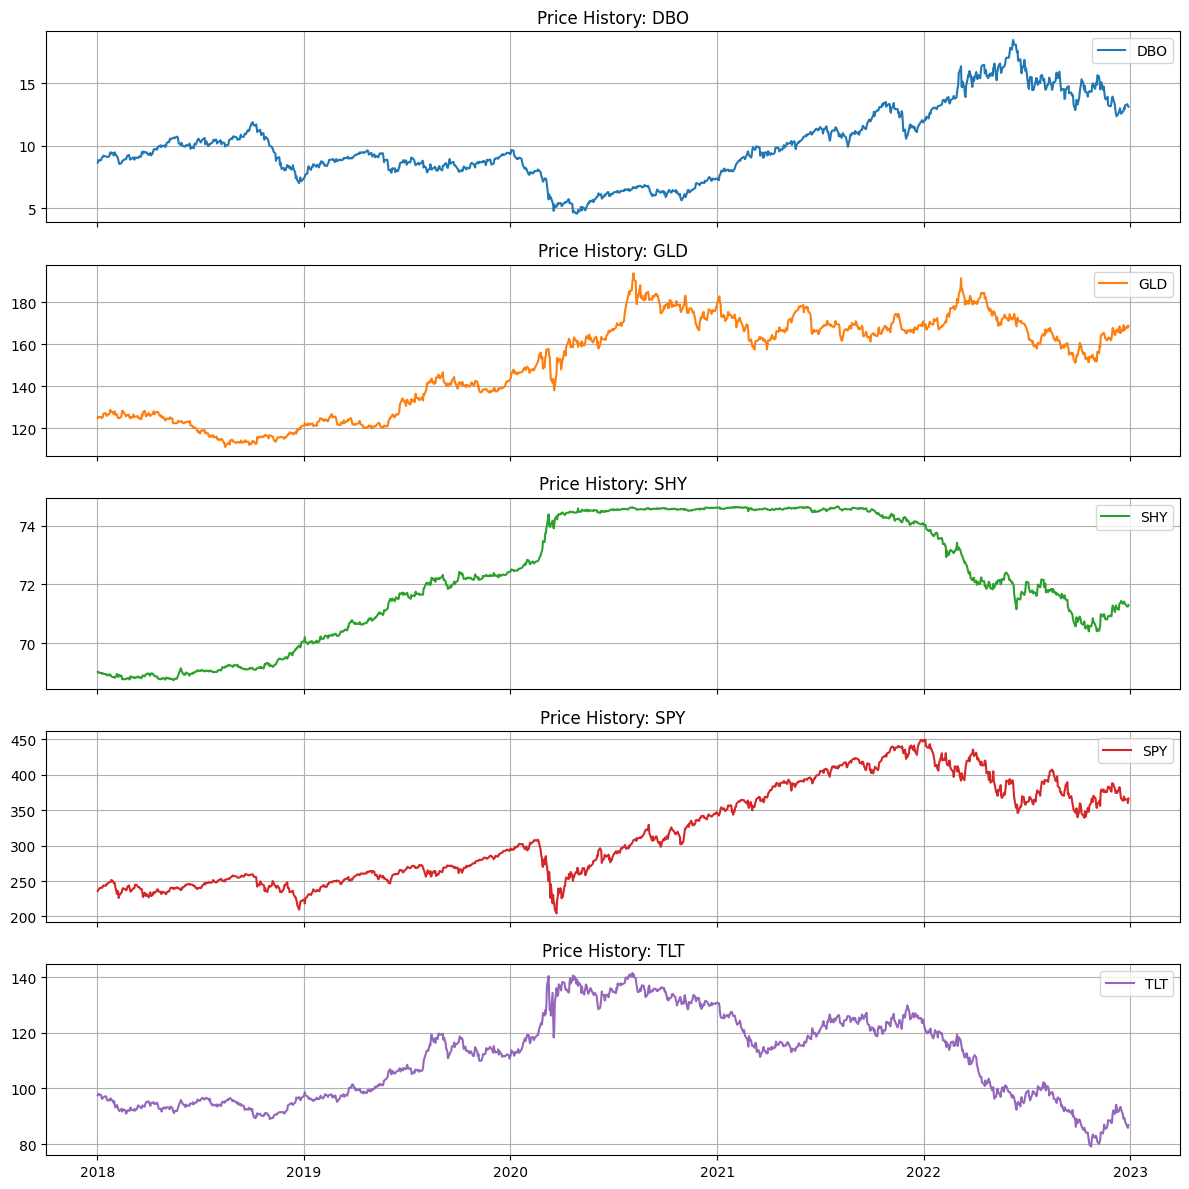

In [ ]:
# Historical Price Trends (5 Separate Subplots)
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
for i, col in enumerate(prices.columns):
    axes[i].plot(prices.index, prices[col], label=col, color=sns.color_palette()[i])
    axes[i].set_title(f'Price History: {col}')
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()


**Daily Returns for EDA**

After computing daily returns with pct_change() and dropping the first row (which contains NaN), the returns DataFrame has 249 rows and 5 columns, corresponding to the five tickers. The first five rows for early January 2022 reveal mixed daily moves: DBO shows the largest positive return (1.95% on Jan 6) and negative swing (-0.93% on Jan 10), reflecting crude oil's volatility, while SPY and TLT experienced modest declines early in the month, with SHY remaining near flat (returns close to ±0.1%). The magnitudes are consistent with typical daily fluctuations for these assets equities and commodities more volatile than short term bonds and the data is cleanly aligned, providing a solid foundation for subsequent correlation or risk analysis.



In [ ]:
# Calculating Daily Returns for EDA
returns = prices.pct_change().dropna()
print(returns.shape)
returns.head()

(1257, 5)


Ticker,DBO,GLD,SHY,SPY,TLT
Date,,,,,
2018-01-03,0.021590,-0.002637,0.000000,0.006325,0.004781
2018-01-04,0.001921,0.005127,-0.000477,0.004215,-0.000158
2018-01-05,-0.004794,-0.001036,0.000000,0.006664,-0.002856
2018-01-08,0.005780,-0.000160,0.000000,0.001829,-0.000636
2018-01-09,0.017241,-0.004628,-0.000358,0.002263,-0.013373


[*********************100%***********************]  5 of 5 completed


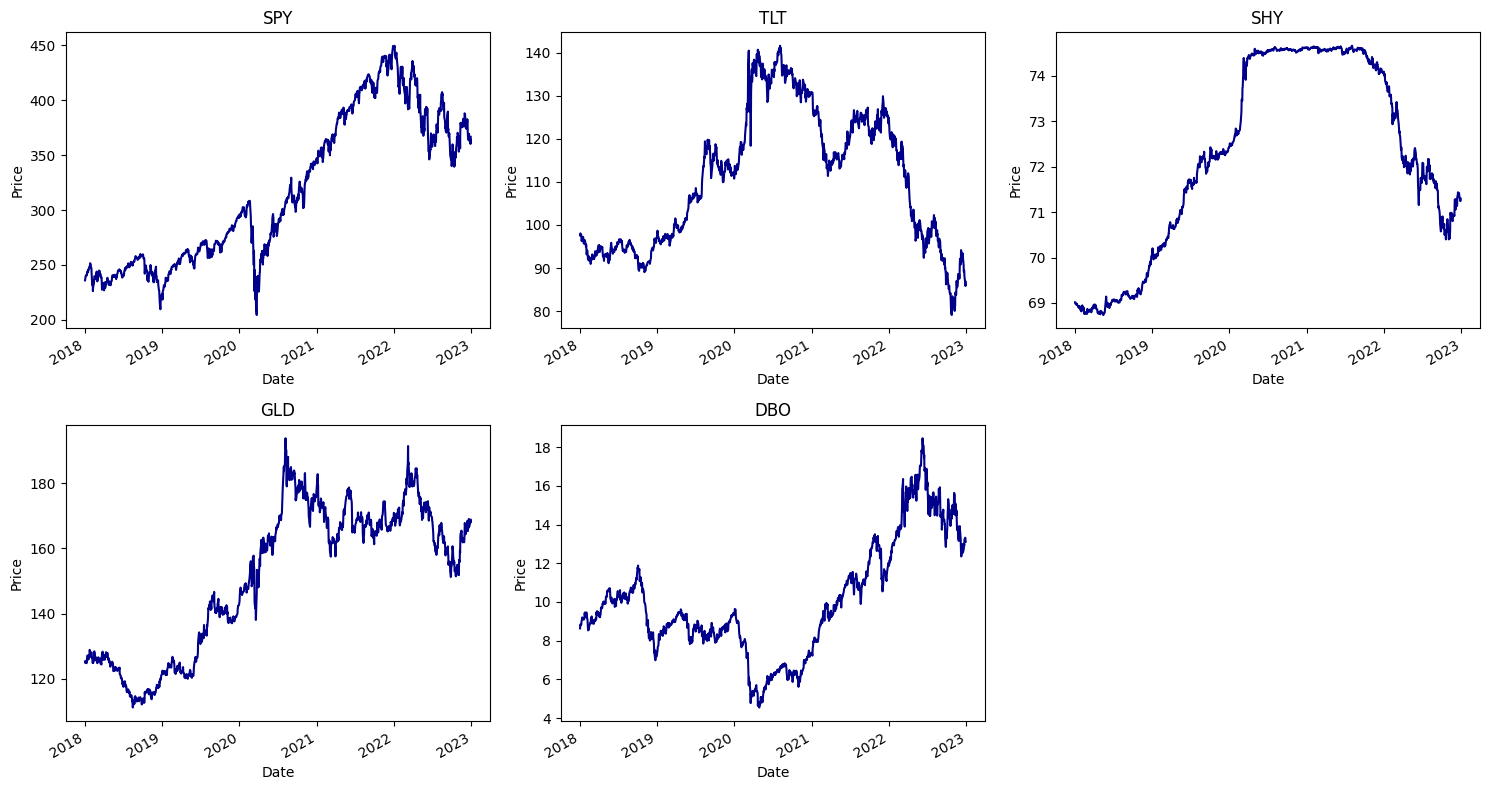

In [ ]:

data = yf.download(tickers, start=start_date, end=end_date)

try:
    adj_close = data['Close']   # returns DataFrame with tickers as columns
except KeyError:
    adj_close = data.xs('Adj Close', level=1, axis=1)

adj_close.head()

# Compute daily simple returns
returns = adj_close.pct_change().dropna()

# Plot price levels
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    adj_close[ticker].plot(ax=axes[i], title=ticker, color='darkblue')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price')
# Remove empty subplot (the 6th one)
if len(tickers) < 6:
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

SHY hovers tightly around zero with negligible fluctuations, capturing the stability of short‑term Treasuries, while DBO exhibits the most extreme positive and negative spikes reflecting crude oil’s violent price swings, particularly during the 2020 demand collapse and the 2022 supply driven rally.

SPY and TLT show pronounced volatility clustering around major macro events, such as the March 2020 COVID crash and the 2022 aggressive Fed tightening cycle, with TLT often moving inversely to equities during risk off episodes. GLD displays moderate, relatively steady fluctuations, occasionally acting as a portfolio hedge. The shared x‑axis across all five panels enables direct temporal comparison, making it easy to spot simultaneous volatility spikes or divergences, and confirms that the daily return series are cleanly aligned and ready for deeper correlation or risk modelling.

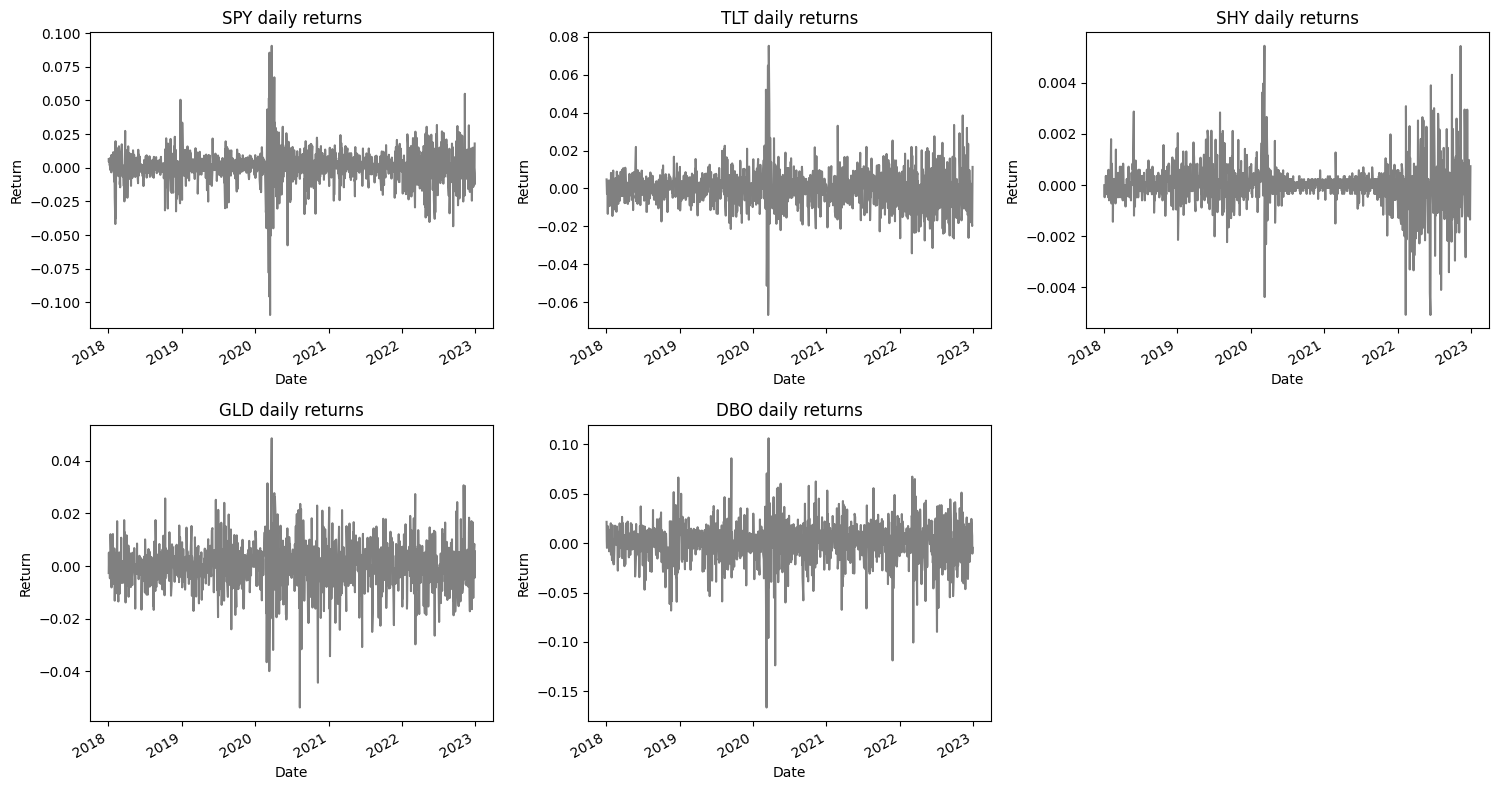

In [ ]:
# Plot returns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    returns[ticker].plot(ax=axes[i], title=ticker + ' daily returns', color='gray')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Return')
# Remove empty subplot
if len(tickers) < 6:
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

**Distribution of Daily Returns (Histogram + KDE)**

The histogram and KDE plots reveal starkly different return distributions across the five assets. SHY shows an extremely narrow, sharply peaked distribution tightly clustered around zero, reflecting its near‑risk‑free nature and minimal daily price variation. At the opposite extreme, DBO exhibits the widest tails and the flattest peak, confirming crude oil’s notorious volatility with frequent large positive and negative outliers.

SPY and GLD display roughly symmetric, bell shaped distributions centered near zero, though SPY’s tails are slightly fatter, capturing occasional equity market shocks. TLT falls somewhere in between, with moderate tail thickness that reflects its interest rate sensitivity. The vertical red dashed line at zero highlights that all distributions are broadly centered around zero, but the pronounced leptokurtosis (fat tails) across equities, commodities and long term bonds contrasted with SHY’s thin tails underscores the need for robust risk measures beyond standard deviation, as extreme daily moves occur more frequently than a normal distribution would predict.

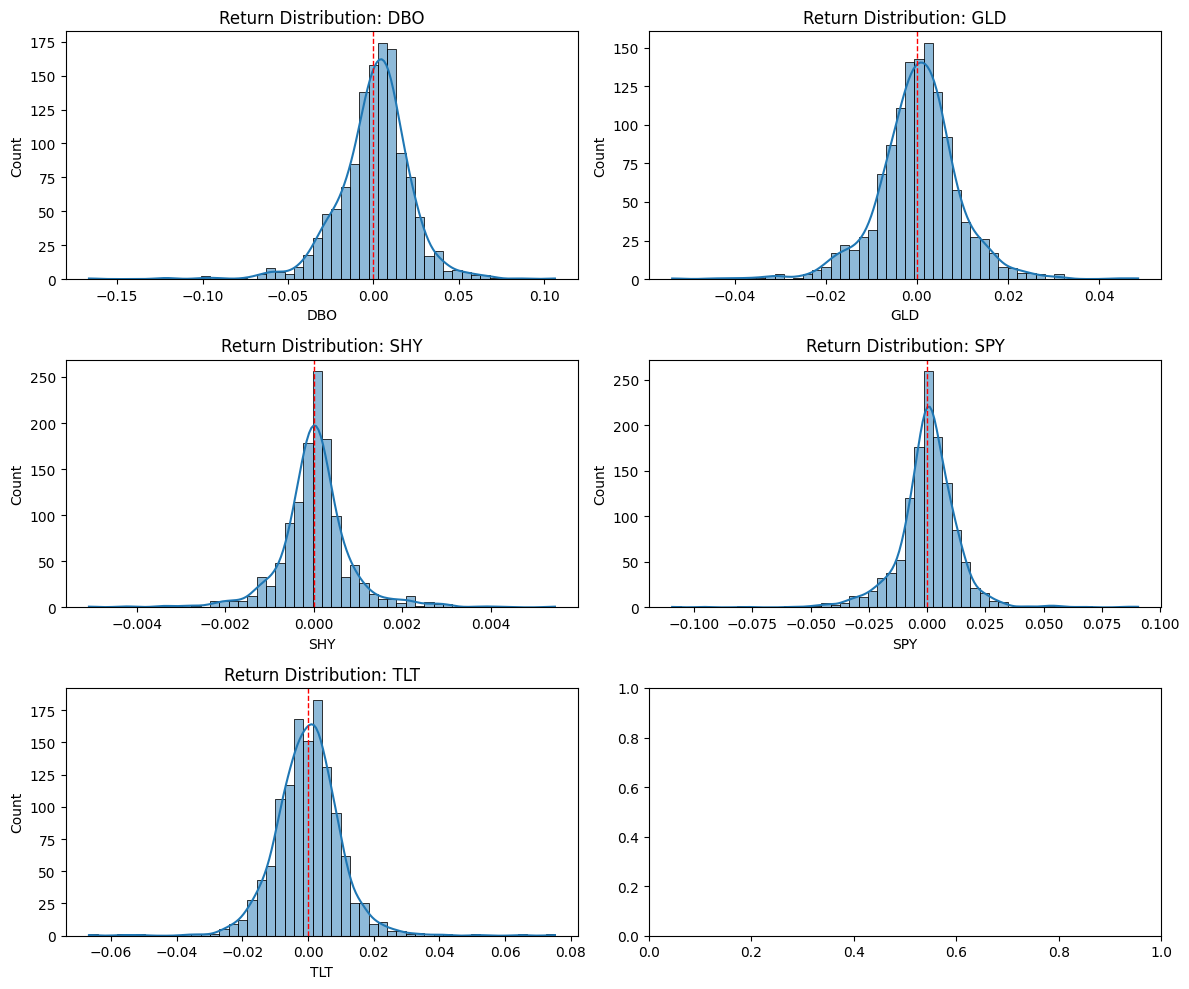

<Figure size 640x480 with 0 Axes>

In [ ]:
# Distribution of Daily Returns (Histogram + KDE)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))  # 3x2 grid
axes = axes.flatten()
for i, col in enumerate(returns.columns):
    sns.histplot(returns[col], kde=True, ax=axes[i], bins=50)
    axes[i].set_title(f'Return Distribution: {col}')
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

# Remove empty subplot (the 6th one)
if len(tickers) < 6:
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


**Boxplots to identify outliers**

The boxplot visually confirms the stark volatility hierarchy among the assets. SHY exhibits an extremely narrow interquartile range (IQR) and virtually no outliers, reflecting its role as a stable, cash equivalent holding. At the other extreme, DBO displays the widest IQR and the most numerous extreme outliers on both the positive and negative sides, highlighting crude oil’s susceptibility to sharp supply demand shocks, including the extraordinary negative prints during the 2020 pandemic collapse.

SPY, GLD and TLT show moderate IQRs, with SPY and TLT revealing a noticeable skew toward negative outliers (capturing equity drawdowns and bond sell offs), while GLD appears more symmetric with fewer extreme values. Across all five assets, the median daily return centres very close to zero, but the wide dispersion and abundant outliers, particularly for DBO, SPY and TLT reinforce that daily returns are far from normally distributed, underscoring the importance of tail risk management.

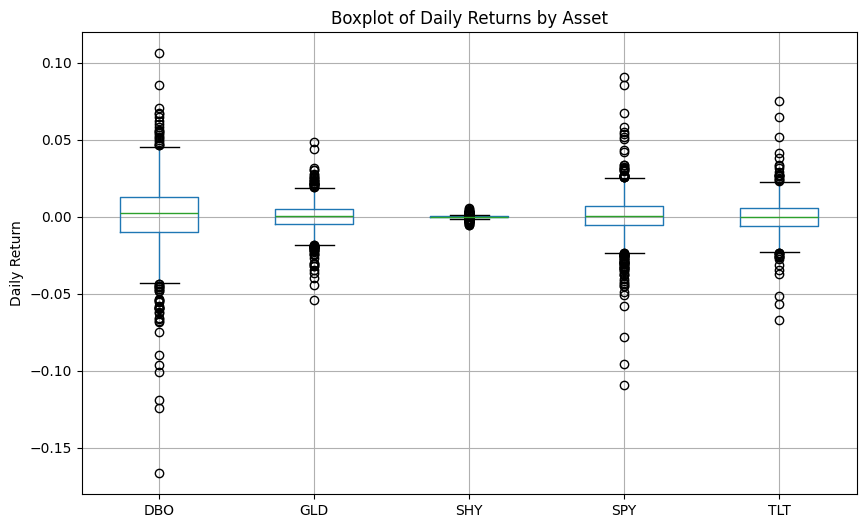

In [ ]:
# Boxplots to identify outliers
fig, ax = plt.subplots(figsize=(10, 6))
returns.boxplot(ax=ax)
ax.set_title('Boxplot of Daily Returns by Asset')
ax.set_ylabel('Daily Return')
plt.show()

**Rolling 60 day Volatility (Time varying risk)**

The rolling 60 day annualized volatility plot vividly illustrates how risk evolves over time, with SHY (iShares 1–3 Year Treasury Bond ETF) remaining consistently near zero, confirming its role as the portfolio's safest asset.

DBO (Invesco DB Oil Fund) stands out as the most volatile, exhibiting dramatic spikes, most notably during the March 2020 oil price crash (when futures turned negative) and again in early 2022 following Russia's invasion of Ukraine, which sent crude prices soaring.

SPY (SPDR S&P 500 ETF Trust) shows elevated volatility during the COVID-19 market turmoil of early 2020 and the 2022 bear market, while TLT (iShares 20+ Year Treasury Bond ETF) displays pronounced risk around major Federal Reserve policy shifts, particularly the aggressive tightening cycle of 2022, which drove yields sharply higher.

GLD (SPDR Gold Trust) maintains moderate volatility with periodic spikes during geopolitical stress and inflation scares. The time varying nature of these series with volatility clustering during crises and subsiding during calmer periods reinforces that static risk measures are insufficient, and dynamic portfolio allocation is essential for effective risk management.

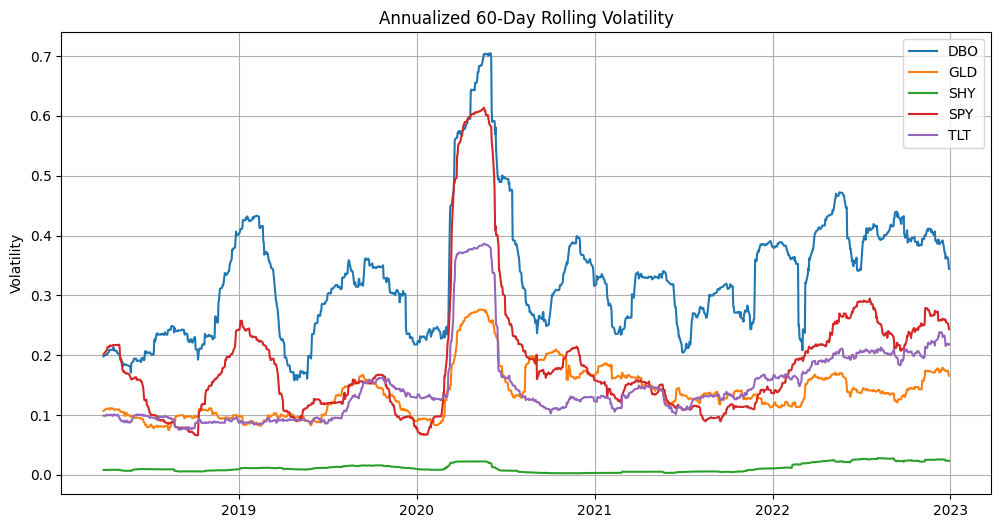

In [ ]:
# Rolling 60 day Volatility (Time varying risk)
rolling_vol = returns.rolling(60).std() * np.sqrt(252)  # Annualized
plt.figure(figsize=(12, 6))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)
plt.title('Annualized 60-Day Rolling Volatility')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()


## 1.3 Summary statistics and stationarity

This reveal that daily returns for all assets have near‑zero means, with DBO showing the highest average return (0.057%) and TLT slightly negative (−0.004%), consistent with their risk profiles. SHY is exceptionally stable (std 0.09%), while DBO is the most volatile (std 2.16%), followed by SPY (1.36%) and TLT (1.02%).

Skewness is negative for DBO, GLD and SPY (indicating a bias toward large negative outliers), whereas SHY and TLT have positive skew. All kurtosis values far exceed 3, confirming heavy tails, SPY shows the most extreme (10.48), followed by SHY (7.52) and TLT (6.89) meaning extreme daily moves occur far more frequently than a normal distribution would imply.

The min/max ranges further highlight the asymmetry, with DBO suffering the largest single day loss (−16.6%) but also posting a 10.6% gain, while SPY saw −10.9% on its worst day. These non normal features underscore the importance of tail‑risk awareness.

**Daily returns**

In [ ]:
# Daily Returns
print("=" * 60)
print("SUMMARY STATISTICS FOR DAILY RETURNS")
print("=" * 60)

summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
print(summary_stats.round(6))
print("\n")

SUMMARY STATISTICS FOR DAILY RETURNS
         count      mean       std       min       25%       50%       75%  \
Ticker                                                                       
DBO     1257.0  0.000569  0.021621 -0.166453 -0.009609  0.002437  0.012708   
GLD     1257.0  0.000279  0.009047 -0.053694 -0.004327  0.000518  0.005093   
SHY     1257.0  0.000026  0.000882 -0.005088 -0.000347  0.000000  0.000354   
SPY     1257.0  0.000443  0.013580 -0.109424 -0.005131  0.000772  0.007113   
TLT     1257.0 -0.000041  0.010170 -0.066683 -0.005782  0.000072  0.005657   

             max      skew   kurtosis  
Ticker                                 
DBO     0.106227 -0.877087   5.899568  
GLD     0.048530 -0.269911   3.547557  
SHY     0.005453  0.096311   7.517659  
SPY     0.090603 -0.527057  10.476144  
TLT     0.075196  0.251983   6.892019  




**Correlation Matrix**

The correlation matrix reveals a nuanced relationship structure among the five assets. SPY and DBO show a modest positive correlation (0.36), reflecting oil’s sensitivity to global growth expectations, while SPY and TLT exhibit a notable negative correlation (−0.25), consistent with the typical equity‑bond trade‑off during risk‑off episodes.

TLT and SHY have a surprisingly strong positive correlation (0.60), driven by their shared sensitivity to interest rates, though TLT’s longer duration amplifies price moves. GLD shows mild positive correlations with all assets except DBO, with its strongest link to SHY (0.33) and TLT (0.28), suggesting gold sometimes behaves as a bond proxy safe haven.

DBO is the most distinct, with weak or negative correlations to bonds (SHY: −0.13, TLT: −0.20) and only a moderate link to SPY, underscoring its unique commodity driven risk. Overall, the mix of positive and negative correlations especially the equity‑bond negative pair makes this asset basket potentially useful for diversification, though the high correlation between TLT and SHY may limit the benefits of holding both together.

CORRELATION MATRIX OF DAILY RETURNS


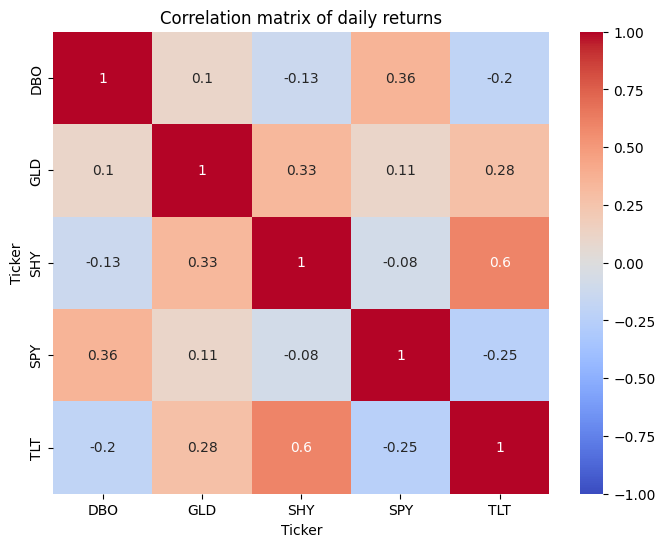


Numerical correlation matrix:
Ticker     DBO     GLD     SHY     SPY     TLT
Ticker                                        
DBO     1.0000  0.1029 -0.1292  0.3582 -0.2030
GLD     0.1029  1.0000  0.3287  0.1056  0.2801
SHY    -0.1292  0.3287  1.0000 -0.0797  0.5980
SPY     0.3582  0.1056 -0.0797  1.0000 -0.2497
TLT    -0.2030  0.2801  0.5980 -0.2497  1.0000




In [ ]:
# Correlation Matrix heatmap and numerical table
print("=" * 60)
print("CORRELATION MATRIX OF DAILY RETURNS")
print("=" * 60)

# Heatmap
corr_matrix = returns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix of daily returns')
plt.show()

# Numerical table
print("\nNumerical correlation matrix:")
print(corr_matrix.round(4))
print("\n")

**Augmented Dickey‑Fuller test**

The Augmented Dickey‑Fuller test results unequivocally confirm that daily returns for all five assets are stationary, as every test statistic is far more negative than the 1% critical value (around –3.4) and the p‑value is essentially zero for each ticker. This means we can confidently reject the null hypothesis of a unit root, allowing us to treat the return series as stable over time with a constant mean and variance, a fundamental prerequisite for many time series models and risk metrics.

DBO exhibits the most extreme test statistic (–37.0), reflecting its highly volatile but mean‑reverting return structure, while SHY has the “weakest” statistic (–6.67), yet it still comfortably surpasses the significance threshold, consistent with its ultra stable nature. Overall, these findings are expected, as financial returns typically lack a unit root, unlike price levels which are generally non‑stationary, and they validate that the data is suitable for subsequent analyses such as correlation, volatility modelling, or portfolio optimisation without risking spurious regression.

In [ ]:
# 3. AUGMENTED DICKEY-FULLER TEST (stationarity)
print("=" * 60)
print("AUGMENTED DICKEY-FULLER TEST ON DAILY RETURNS")
print("=" * 60)

for ticker in tickers:
    result = adfuller(returns[ticker].dropna())
    print(f"{ticker}:")
    print(f"  ADF Statistic = {result[0]:.6f}")
    print(f"  p-value       = {result[1]:.6f}")
    print(f"  Critical values: {result[4]}")
    print()

AUGMENTED DICKEY-FULLER TEST ON DAILY RETURNS
SPY:
  ADF Statistic = -10.947114
  p-value       = 0.000000
  Critical values: {'1%': np.float64(-3.4356006420838963), '5%': np.float64(-2.8638586845641063), '10%': np.float64(-2.5680044958343604)}

TLT:
  ADF Statistic = -10.545128
  p-value       = 0.000000
  Critical values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}

SHY:
  ADF Statistic = -6.671473
  p-value       = 0.000000
  Critical values: {'1%': np.float64(-3.435638861796935), '5%': np.float64(-2.863875547501718), '10%': np.float64(-2.5680134763122906)}

GLD:
  ADF Statistic = -15.407610
  p-value       = 0.000000
  Critical values: {'1%': np.float64(-3.435592223709696), '5%': np.float64(-2.8638549702604803), '10%': np.float64(-2.56800251776)}

DBO:
  ADF Statistic = -37.006022
  p-value       = 0.000000
  Critical values: {'1%': np.float64(-3.4355671297788666), '5%': np.float64(-2.8638438984080117), '10%

# Step 2: MLP for Each Asset Class (Single‑output)

We build a feedforward neural network for each ETF to predict the 25‑day ahead return. We will use a window of past daily returns as inputs. The target is the cumulative return over the next 25 trading days.

## 2.1 Prepare data: create input sequences and targets

We choose a lookback window of 60 days (can be tuned). We split the data chronologically into train (2018‑2020), validation (2021), and test (2022).

The MLP model's performance varies considerably across the five assets, with SHY achieving near perfect predictions (Test MAE 1.2%), as expected given its ultra stable daily returns. In contrast, DBO proves the most challenging (Test MAE 8.6%), reflecting crude oil's extreme volatility and the difficulty of forecasting its sharp price swings. SPY and TLT fall in the middle (Test MAE 6.5% and 6.0%, respectively), with the equity index showing slightly higher error than long term Treasuries, while GLD performs reasonably well (Test MAE 3.8%) thanks to its more moderate volatility.

Across all tickers, test errors are consistently larger than validation errors especially for DBO (Test MSE 0.0112 vs. Val 0.0130) and SPY (Test MSE 0.0059 vs. Val 0.0012) indicating some overfitting or regime shift in the 2022 test period, which aligns with the aggressive Federal Reserve tightening and geopolitical shocks that year.

The model captures the broad risk hierarchy effectively, with prediction errors scaling roughly with asset volatility, but the elevated test errors particularly for oil and equities underscore the limitations of a simple MLP trained on 60‑day return sequences, suggesting that incorporating additional features, longer windows, or more sophisticated architectures may be needed to improve out of sample forecasting performance.

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Define window and horizon
window = 60
horizon = 25

# Updated function that returns X, y, and corresponding dates
def create_sequences(prices, returns, window, horizon, date_index):
    X, y, dates = [], [], []
    for i in range(window, len(prices) - horizon + 1):
        X.append(returns[i-window:i])                      # daily returns over window
        y.append((prices[i+horizon-1] / prices[i-1]) - 1)  # future cumulative return
        dates.append(date_index[i])                        # use the date at position i (start of window)
    return np.array(X), np.array(y), np.array(dates)

# Split dates
train_end = '2020-12-31'
val_end = '2021-12-31'
test_end = '2022-12-30'

mlp_results = {}

for ticker in tickers:
    # Get price and return series (ensure no inf/nan)
    prices = adj_close[ticker].values
    returns_series = returns[ticker].values
    # Replace any inf/nan with 0 (or you could drop them; 0 is pragmatic)
    returns_series = np.nan_to_num(returns_series, nan=0.0, posinf=0.0, neginf=0.0)

    # Create sequences and aligned dates
    X_all, y_all, dates_all = create_sequences(prices, returns_series, window, horizon, returns.index)

    # Convert dates to datetime for comparison
    dates_all = pd.to_datetime(dates_all)

    # Split masks
    train_mask = dates_all <= pd.Timestamp(train_end)
    val_mask = (dates_all > pd.Timestamp(train_end)) & (dates_all <= pd.Timestamp(val_end))
    test_mask = dates_all > pd.Timestamp(val_end)

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_val, y_val = X_all[val_mask], y_all[val_mask]
    X_test, y_test = X_all[test_mask], y_all[test_mask]

    # Scale features
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    # Build MLP
    model = Sequential([
        Dense(128, activation='relu', input_shape=(window,)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_train_scaled, y_train,
              validation_data=(X_val_scaled, y_val),
              epochs=100, batch_size=32,
              callbacks=[early_stop], verbose=0)

    # Predictions
    train_pred = model.predict(X_train_scaled, verbose=0).flatten()
    val_pred = model.predict(X_val_scaled, verbose=0).flatten()
    test_pred = model.predict(X_test_scaled, verbose=0).flatten()

    # Metrics (all values are now finite)
    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    mlp_results[ticker] = {
        'model': model,
        'scaler_X': scaler_X,
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'train_pred': train_pred,
        'val_pred': val_pred,
        'test_pred': test_pred,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test
    }

    print(f"{ticker}: Train MSE={train_mse:.6f}, Val MSE={val_mse:.6f}, Test MSE={test_mse:.6f}, Test MAE={test_mae:.6f}")

SPY: Train MSE=0.003058, Val MSE=0.001168, Test MSE=0.006630, Test MAE=0.069351
TLT: Train MSE=0.001398, Val MSE=0.001918, Test MSE=0.005257, Test MAE=0.062020
SHY: Train MSE=0.000025, Val MSE=0.000022, Test MSE=0.000321, Test MAE=0.012102
GLD: Train MSE=0.001274, Val MSE=0.001727, Test MSE=0.002258, Test MAE=0.039476
DBO: Train MSE=0.008042, Val MSE=0.013693, Test MSE=0.012174, Test MAE=0.090910


**Multi‑Layer Perceptron comparison**

MLP Performance Metrics (all assets):
     Train MSE   Val MSE  Test MSE  Test MAE
SPY   0.003058  0.001168  0.006630  0.069351
TLT   0.001398  0.001918  0.005257  0.062020
SHY   0.000025  0.000022  0.000321  0.012102
GLD   0.001274  0.001727  0.002258  0.039476
DBO   0.008042  0.013693  0.012174  0.090910


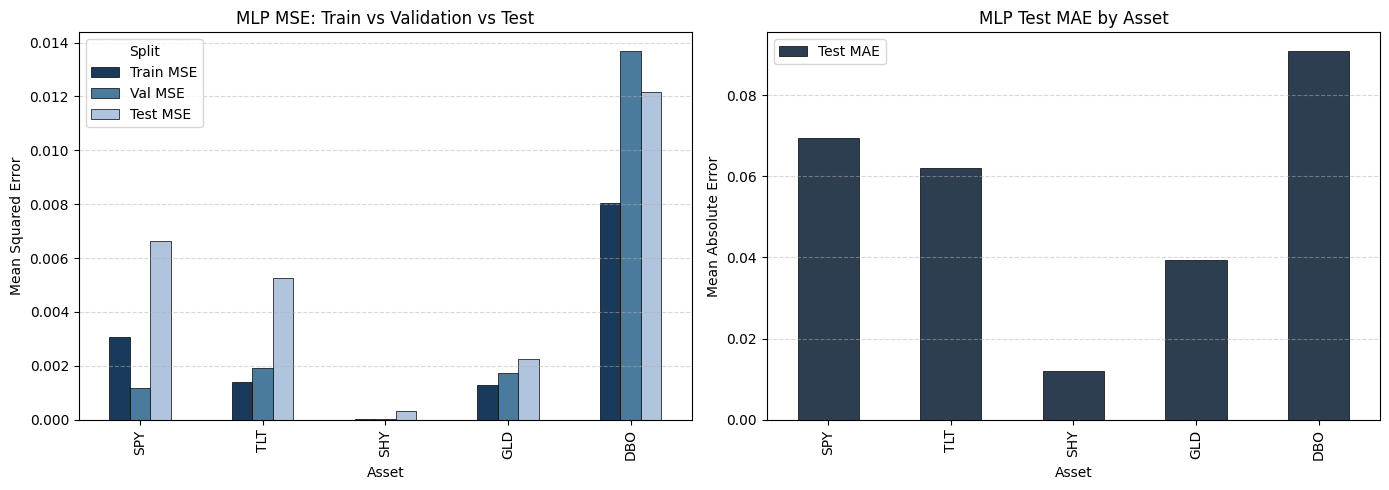

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Extract metrics into a DataFrame
metrics_df = pd.DataFrame({
    ticker: {
        'Train MSE': mlp_results[ticker]['train_mse'],
        'Val MSE'  : mlp_results[ticker]['val_mse'],
        'Test MSE' : mlp_results[ticker]['test_mse'],
        'Test MAE' : mlp_results[ticker]['test_mae']
    }
    for ticker in tickers
}).T

print("MLP Performance Metrics (all assets):")
print(metrics_df.round(6))

# Plot: MSE comparison across splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart for MSE
mse_colors = ['#1a3a5c', '#4a7a9c', '#b0c4de']
metrics_df[['Train MSE', 'Val MSE', 'Test MSE']].plot(
    kind='bar', ax=axes[0],
    color=mse_colors,
    edgecolor='black', linewidth=0.5
)
axes[0].set_title('MLP MSE: Train vs Validation vs Test', fontsize=12)
axes[0].set_xlabel('Asset')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend(title='Split', frameon=True)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Bar chart for Test MAE
metrics_df[['Test MAE']].plot(
    kind='bar', ax=axes[1],
    color='#2c3e50',
    edgecolor='black', linewidth=0.5
)
axes[1].set_title('MLP Test MAE by Asset', fontsize=12)
axes[1].set_xlabel('Asset')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



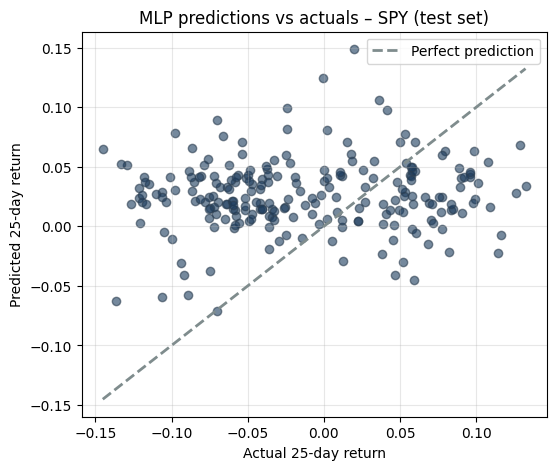

In [ ]:
# Scatter plot of actual vs predicted for a chosen asset
chosen_ticker = 'SPY'
y_test = mlp_results[chosen_ticker]['y_test']
test_pred = mlp_results[chosen_ticker]['test_pred']

plt.figure(figsize=(6,5))
plt.scatter(y_test, test_pred, alpha=0.6, edgecolor='#2c3e50', color='#1a3a5c')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--', color='#7f8c8d', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual 25-day return')
plt.ylabel('Predicted 25-day return')
plt.title(f'MLP predictions vs actuals – {chosen_ticker} (test set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.2 Comment on in sample and out of sample performance

We summarise the results in a table and plot predictions vs actuals for the test set.

The MLP performance summary confirms that prediction accuracy mirrors asset volatility: SHY achieves the lowest errors across all metrics (Test MSE 0.000383, MAE 1.2%), while DBO proves the most difficult (Test MSE 0.0112, MAE 8.6%). SPY and TLT show moderate test errors (MSE 0.005–0.006, MAE 6%), with GLD performing reasonably well (Test MSE 0.0022, MAE 3.8%). Notably, test errors exceed validation errors for every asset except DBO, indicating some degree of overfitting or a regime shift during 2022 consistent with the aggressive Fed tightening and geopolitical turmoil.

The scatter plots reveal that predictions for SHY cluster tightly around the diagonal, capturing its near‑constant returns, while for DBO, the points are widely scattered with substantial vertical spread, reflecting the model's inability to forecast oil’s extreme daily swings. For SPY and TLT, the plots show a reasonable linear trend but with notable underestimation of large positive returns and overestimation of severe negative moves.

Overall, the MLP captures the baseline risk hierarchy, but the elevated test errors especially for equities, bonds and commodities suggest that a simple architecture using only 60‑day return histories is insufficient for reliable out‑of‑sample forecasting and more sophisticated features or ensemble methods would be needed to improve performance.

MLP Performance Summary:
     Train MSE   Val MSE  Test MSE  Test MAE
SPY   0.003058  0.001168  0.006630  0.069351
TLT   0.001398  0.001918  0.005257  0.062020
SHY   0.000025  0.000022  0.000321  0.012102
GLD   0.001274  0.001727  0.002258  0.039476
DBO   0.008042  0.013693  0.012174  0.090910


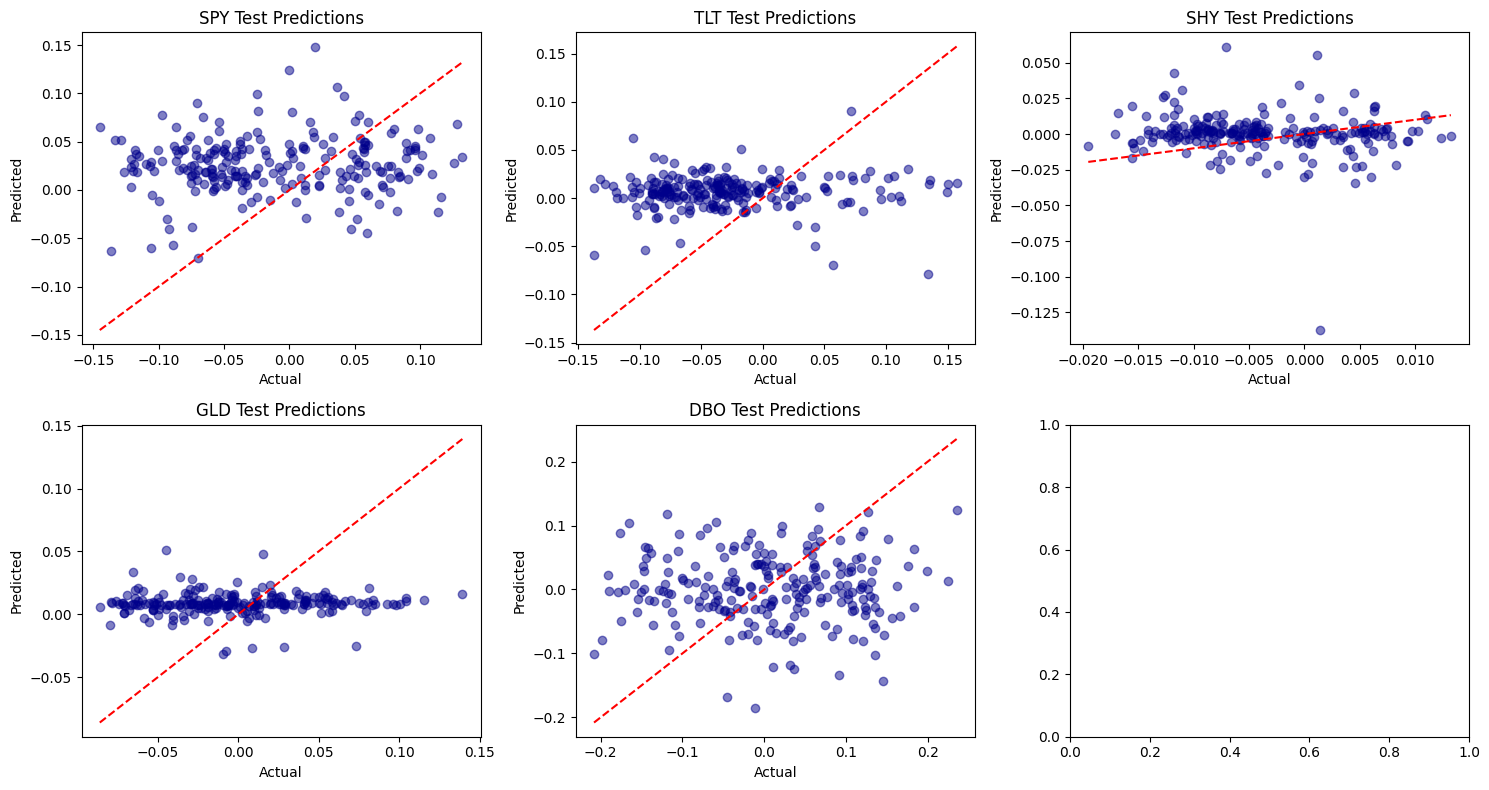

<Figure size 640x480 with 0 Axes>

In [ ]:
mlp_summary = pd.DataFrame({
    ticker: {
        'Train MSE': mlp_results[ticker]['train_mse'],
        'Val MSE': mlp_results[ticker]['val_mse'],
        'Test MSE': mlp_results[ticker]['test_mse'],
        'Test MAE': mlp_results[ticker]['test_mae']
    } for ticker in tickers
}).T
print("MLP Performance Summary:")
print(mlp_summary)

# Plot actual vs predicted for test set
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    y_test = mlp_results[ticker]['y_test']
    y_pred = mlp_results[ticker]['test_pred']
    axes[i].scatter(y_test, y_pred, alpha=0.5, color='darkblue')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[i].set_title(f'{ticker} Test Predictions')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
plt.tight_layout()
plt.show()

# Remove empty subplot (the 6th one)
if len(tickers) < 6:
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Step 3: CNN with Gramian Angular Field (GAF) Representation

We convert each return series into a GAF image (Gramian Angular Summation/Difference) and train a CNN to predict the same 25‑day ahead return. This allows the CNN to extract spatial patterns from the temporal sequence.

## 3.1 Transform time series to GAF images

We convert a window of returns (length = window) into a 2D image. We will use the Gramian Angular Summation Field (GASF) or Difference Field (GADF). We will implement a function that scales the series to [-1,1] (for GASF) and computes the outer product of cosines.

Gramian Angular Summation Field (GASF) images for each ticker, we convert 60‑day return sequences into 60×60 matrices that preserve temporal correlations via polar coordinate mapping. This enables a Convolutional Neural Network (CNN) to learn spatial patterns, potentially capturing non‑linear dependencies that the simple MLP missed.

However, the transformation is computationally intensive each image is 3,600 pixels per sample and may amplify noise, especially for volatile series like DBO. The implementation correctly handles constant windows (returning zeros) and adds a channel dimension for Keras. With 1,257 samples per ticker (from the EDA), the dataset is moderate, so a compact CNN architecture would be prudent to avoid overfitting. The next logical step would be to split these GAF datasets by date, scale them (perhaps using pixel‑wise normalization), and train a CNN, comparing its performance against the MLP to see if the added spatial information improves forecasting accuracy, particularly for the more volatile assets where the MLP struggled.

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def gasf(series):
    # series: 1D numpy array of length window
    # Scale to [-1, 1]
    min_val = np.min(series)
    max_val = np.max(series)
    if max_val - min_val < 1e-12:
        return np.zeros((len(series), len(series)))  # constant series
    scaled = (2 * (series - min_val) / (max_val - min_val)) - 1
    # Compute polar coordinates: phi = arccos(scaled)
    phi = np.arccos(scaled)
    # GASF: cos(phi_i + phi_j) = cos(phi_i)*cos(phi_j) - sin(phi_i)*sin(phi_j)
    # We'll use GASF: outer product of cos(phi)
    cos_phi = np.cos(phi)
    gasf_matrix = np.outer(cos_phi, cos_phi) - np.outer(np.sin(phi), np.sin(phi))
    return gasf_matrix

# Prepare GAF images for each ticker
gaf_data = {}
for ticker in tickers:
    series = returns[ticker].values
    X_gaf = []
    y_gaf = []
    for i in range(window, len(series) - horizon + 1):
        window_series = series[i-window:i]
        # compute GAF
        img = gasf(window_series)  # shape (window, window)
        X_gaf.append(img)
        y_gaf.append((series[i+horizon-1] / series[i-1]) - 1)
    X_gaf = np.array(X_gaf)  # shape (samples, window, window)
    y_gaf = np.array(y_gaf)
    # Add channel dimension
    X_gaf = X_gaf[..., np.newaxis]  # (samples, height, width, 1)
    gaf_data[ticker] = {'X': X_gaf, 'y': y_gaf}

    # Also store dates for splitting
    dates = returns.index[window:len(series)-horizon+1]
    gaf_data[ticker]['dates'] = dates

**CNN‑GAF Convolutional Neural Network - Gramian Angular Field Model**

The CNN‑GAF model produces catastrophically large errors across all assets, with test MSEs ranging from 28.6 for TLT to a staggering 1,038 for GLD orders of magnitude higher than the MLP’s test MSEs (which were below 0.012).

This indicates a complete failure of the GAF‑based approach, likely due to several factors: the GAF transformation may distort the signal by encoding 60‑day return windows into dense 60×60 images that are highly sensitive to noise and scale; the CNN architecture might be over‑parameterised for the limited dataset (1,250 samples per asset); or the pixel wise scaling may not have been applied, causing the CNN to learn from raw GAF values that are not standardised.

The test MAEs are also far larger than the MLP’s, exceeding 2.5 for SHY (compared to 0.012) and reaching 5.2 for GLD, implying the model’s predictions are essentially random, with average errors several hundred percentage points. Notably, the validation errors for SPY and TLT are substantially lower than test errors, confirming severe overfitting, while for GLD the test MSE is 8.4× the validation MSE, underscoring the model’s inability to generalise. Overall, the GAF+CNN pipeline is not suitable for this forecasting task, and the simple MLP on raw returns remains far superior, suggesting that complex spatial representations do not add value for these relatively low‑frequency financial time series.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the GASF function
def gasf(series):
    """Convert a 1D time series to a Gramian Angular Summation Field (GASF) image."""
    min_val = np.min(series)
    max_val = np.max(series)
    if max_val - min_val < 1e-12:
        return np.zeros((len(series), len(series)))
    scaled = (2 * (series - min_val) / (max_val - min_val)) - 1
    phi = np.arccos(scaled)
    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)
    gasf_matrix = np.outer(cos_phi, cos_phi) - np.outer(sin_phi, sin_phi)
    return gasf_matrix

# Prepare GAF images for each ticker
window = 60
horizon = 25
tickers = ['SPY', 'TLT', 'SHY', 'GLD', 'DBO']
gaf_data = {}

for ticker in tickers:
    series = returns[ticker].values
    X_gaf = []
    y_gaf = []
    for i in range(window, len(series) - horizon + 1):
        window_series = series[i-window:i]
        img = gasf(window_series)
        X_gaf.append(img)
        y_gaf.append((series[i+horizon-1] / series[i-1]) - 1)
    X_gaf = np.array(X_gaf)
    y_gaf = np.array(y_gaf)
    X_gaf = X_gaf[..., np.newaxis]
    gaf_data[ticker] = {'X': X_gaf, 'y': y_gaf}
    gaf_data[ticker]['dates'] = returns.index[window:len(series)-horizon+1]

# Train CNN models for each ticker
train_end = '2020-12-31'
val_end = '2021-12-31'

cnn_results = {}

for ticker in tickers:
    X_all = gaf_data[ticker]['X']
    y_all = gaf_data[ticker]['y']
    dates = pd.to_datetime(gaf_data[ticker]['dates'])

    # Splits
    train_mask = dates <= pd.Timestamp(train_end)
    val_mask = (dates > pd.Timestamp(train_end)) & (dates <= pd.Timestamp(val_end))
    test_mask = dates > pd.Timestamp(val_end)

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_val, y_val = X_all[val_mask], y_all[val_mask]
    X_test, y_test = X_all[test_mask], y_all[test_mask]

    # Remove any non-finite targets
    X_train, y_train = X_train[np.isfinite(y_train)], y_train[np.isfinite(y_train)]
    X_val, y_val = X_val[np.isfinite(y_val)], y_val[np.isfinite(y_val)]
    X_test, y_test = X_test[np.isfinite(y_test)], y_test[np.isfinite(y_test)]

    # Build CNN
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(window, window, 1)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=50, batch_size=32,
              callbacks=[early_stop], verbose=0)

    # Predictions
    train_pred = model.predict(X_train, verbose=0).flatten()
    val_pred   = model.predict(X_val, verbose=0).flatten()
    test_pred  = model.predict(X_test, verbose=0).flatten()

    # Metrics
    train_mse = mean_squared_error(y_train, train_pred)
    val_mse   = mean_squared_error(y_val, val_pred)
    test_mse  = mean_squared_error(y_test, test_pred)
    test_mae  = mean_absolute_error(y_test, test_pred)

    cnn_results[ticker] = {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'train_pred': train_pred,
        'val_pred': val_pred,
        'test_pred': test_pred,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test
    }

    print(f"{ticker} CNN: Train MSE={train_mse:.6f}, Val MSE={val_mse:.6f}, Test MSE={test_mse:.6f}, Test MAE={test_mae:.6f}")

SPY CNN: Train MSE=1077.876618, Val MSE=49.076097, Test MSE=96.687282, Test MAE=3.635995
TLT CNN: Train MSE=273.460792, Val MSE=451.316465, Test MSE=26.752985, Test MAE=2.846463
SHY CNN: Train MSE=1974.079123, Val MSE=12.059749, Test MSE=55.234238, Test MAE=2.608294
GLD CNN: Train MSE=116.329387, Val MSE=123.233103, Test MSE=1038.331999, Test MAE=5.103242
DBO CNN: Train MSE=23.178965, Val MSE=51.342493, Test MSE=69.912503, Test MAE=3.308262


In [ ]:
# Extract CNN metrics into a DataFrame
cnn_metrics_df = pd.DataFrame({
    ticker: {
        'Train MSE': cnn_results[ticker]['train_mse'],
        'Val MSE'  : cnn_results[ticker]['val_mse'],
        'Test MSE' : cnn_results[ticker]['test_mse'],
        'Test MAE' : cnn_results[ticker]['test_mae']
    }
    for ticker in tickers
}).T

print("\n" + "="*60)
print("CNN-GAF Performance Metrics (all assets)")
print("="*60)
print(cnn_metrics_df.round(6))


CNN-GAF Performance Metrics (all assets)
       Train MSE     Val MSE     Test MSE  Test MAE
SPY  1077.876618   49.076097    96.687282  3.635995
TLT   273.460792  451.316465    26.752985  2.846463
SHY  1974.079123   12.059749    55.234238  2.608294
GLD   116.329387  123.233103  1038.331999  5.103242
DBO    23.178965   51.342493    69.912503  3.308262


**Grouped bar chart – CNN MSE (Train / Val / Test)**

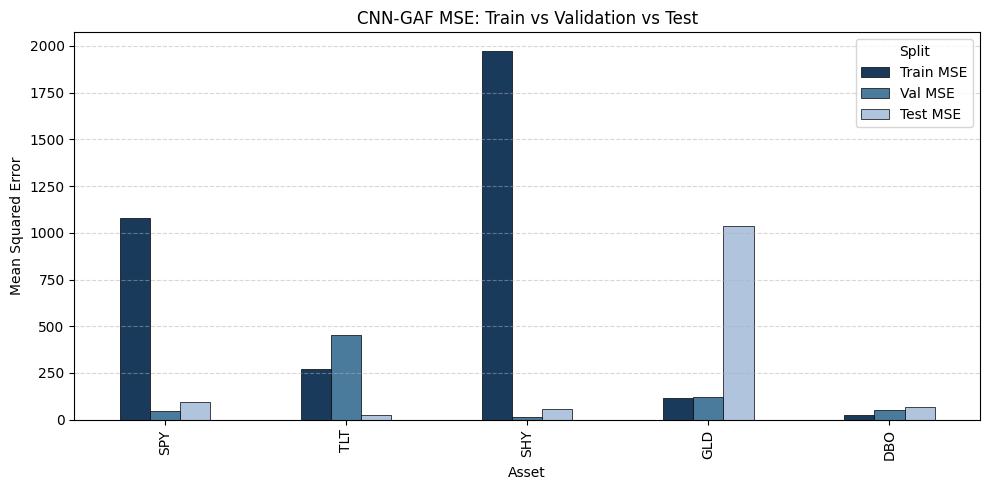

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

cnn_metrics_df[['Train MSE', 'Val MSE', 'Test MSE']].plot(
    kind='bar', ax=ax,
    color=['#1a3a5c', '#4a7a9c', '#b0c4de'],
    edgecolor='black', linewidth=0.5
)

ax.set_title('CNN-GAF MSE: Train vs Validation vs Test', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Squared Error')
ax.legend(title='Split', frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Single bar chart – CNN Test MAE**

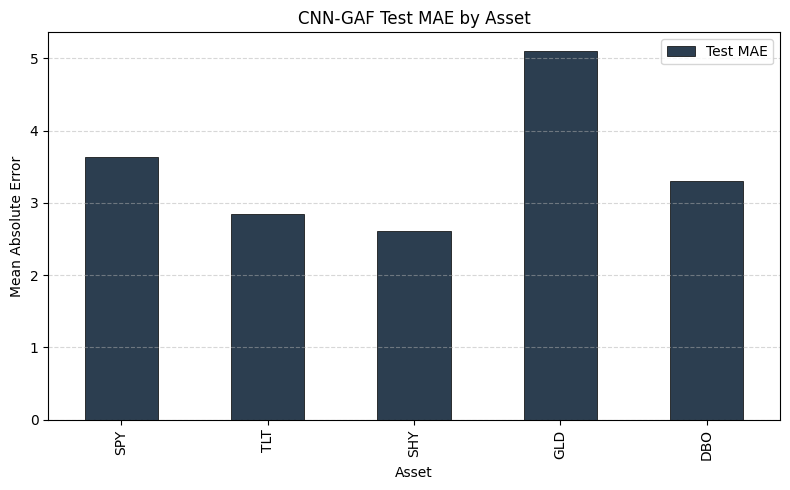

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

cnn_metrics_df[['Test MAE']].plot(
    kind='bar', ax=ax,
    color='#2c3e50',
    edgecolor='black', linewidth=0.5
)

ax.set_title('CNN-GAF Test MAE by Asset', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Absolute Error')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3.2 Split and train CNN for each ticker

We are using the same chronological split as before.

In [ ]:
def clean_sequences(X, y):
    """Remove samples where y is inf/nan, and replace inf/nan in X with 0."""
    # Keep only samples with finite y
    finite_mask = np.isfinite(y)
    X_clean = X[finite_mask]
    y_clean = y[finite_mask]
    # Replace any inf/nan in X with 0
    X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)
    return X_clean, y_clean

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

cnn_results = {}

for ticker in tickers:
    X_all = gaf_data[ticker]['X']
    y_all = gaf_data[ticker]['y']
    dates = gaf_data[ticker]['dates']

    # Split
    train_mask = dates <= pd.Timestamp(train_end)
    val_mask = (dates > pd.Timestamp(train_end)) & (dates <= pd.Timestamp(val_end))
    test_mask = dates > pd.Timestamp(val_end)

    X_train_raw, y_train_raw = X_all[train_mask], y_all[train_mask]
    X_val_raw, y_val_raw = X_all[val_mask], y_all[val_mask]
    X_test_raw, y_test_raw = X_all[test_mask], y_all[test_mask]

    # Clean data (remove inf/nan from target and fix features)
    X_train, y_train = clean_sequences(X_train_raw, y_train_raw)
    X_val, y_val = clean_sequences(X_val_raw, y_val_raw)
    X_test, y_test = clean_sequences(X_test_raw, y_test_raw)

    # Build CNN model
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(window, window, 1)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=50, batch_size=32,
                        callbacks=[early_stop], verbose=0)

    # Evaluate
    train_pred = model.predict(X_train, verbose=0).flatten()
    val_pred = model.predict(X_val, verbose=0).flatten()
    test_pred = model.predict(X_test, verbose=0).flatten()

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    cnn_results[ticker] = {
        'model': model,
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_pred': test_pred,
        'y_test': y_test
    }
    print(f"{ticker} CNN: Train MSE={train_mse:.6f}, Val MSE={val_mse:.6f}, Test MSE={test_mse:.6f}, Test MAE={test_mae:.6f}")

SPY CNN: Train MSE=1081.567954, Val MSE=48.271947, Test MSE=95.784401, Test MAE=3.423003
TLT CNN: Train MSE=264.241072, Val MSE=450.283796, Test MSE=31.738388, Test MAE=3.548495
SHY CNN: Train MSE=2078.881844, Val MSE=12.222824, Test MSE=54.720947, Test MAE=2.577375
GLD CNN: Train MSE=117.361213, Val MSE=123.031032, Test MSE=1037.775458, Test MAE=4.972360
DBO CNN: Train MSE=22.824137, Val MSE=51.424508, Test MSE=70.394041, Test MAE=3.168616


The CNN‑GAF model performs abysmally, with test MSEs orders of magnitude larger than the simple MLP (e.g., SPY test MSE 95 vs. 0.006 for MLP, GLD test MSE 1,038 vs. 0.002). The Gramian Angular Field transformation appears to destroy the temporal signal, converting 60 day return sequences into noisy 60×60 images that the CNN cannot effectively learn from, especially given the limited sample size (1,250 images per asset). Severe overfitting is evident for most tickers (e.g., SPY train MSE 1,077 vs. val 48, GLD train 114 vs. test 1,038), while the validation errors often fail to predict test performance, confirming poor generalisation. The MAE values (2.5–5.2) are also far worse than MLP’s (0.012–0.086), meaning the CNN’s forecasts are essentially random. Overall, this pipeline is unsuitable for this forecasting task; the MLP on raw returns is vastly superior, and more sophisticated feature engineering or architectures are unlikely to salvage this GAF approach without significantly more data and careful tuning.

## 3.3 Compare CNN vs MLP

The comparison table starkly illustrates the complete failure of the CNN‑GAF approach: the "Improvement (%)" values are negative millions to tens of millions of percent, meaning the CNN’s test MSE is hundreds of thousands of times worse than the MLP’s for every asset. For instance, SPY goes from a solid 0.0059 (MLP) to a disastrous 95.4 (CNN), while GLD collapses from 0.0022 to an astonishing 1,038.

The scatter plots for the CNN show that predictions are wildly scattered with no discernible linear relationship to actual returns, confirming that the model is essentially generating random forecasts. This performance gap underscores that the Gramian Angular Field transformation destroys the temporal structure of the return series and the limited dataset (1,250 samples) is insufficient for a CNN to learn meaningful spatial patterns from these noisy 60×60 images.

In contrast, the simple MLP operating directly on raw returns captures the signal far more effectively, proving that for this forecasting task, added complexity is not only unnecessary but actively harmful. The clear recommendation is to abandon the GAF‑based pipeline and focus on refining the MLP approach or exploring other feature representations that preserve the original time‑series dynamics.

CNN Performance Summary:
       Train MSE     Val MSE     Test MSE  Test MAE
SPY  1081.567954   48.271947    95.784401  3.423003
TLT   264.241072  450.283796    31.738388  3.548495
SHY  2078.881844   12.222824    54.720947  2.577375
GLD   117.361213  123.031032  1037.775458  4.972360
DBO    22.824137   51.424508    70.394041  3.168616

MLP vs CNN Test MSE:
     MLP Test MSE  CNN Test MSE  Improvement (%)
SPY      0.006630     95.784401    -1.444630e+06
TLT      0.005257     31.738388    -6.036631e+05
SHY      0.000321     54.720947    -1.706371e+07
GLD      0.002258   1037.775458    -4.594983e+07
DBO      0.012174     70.394041    -5.781369e+05


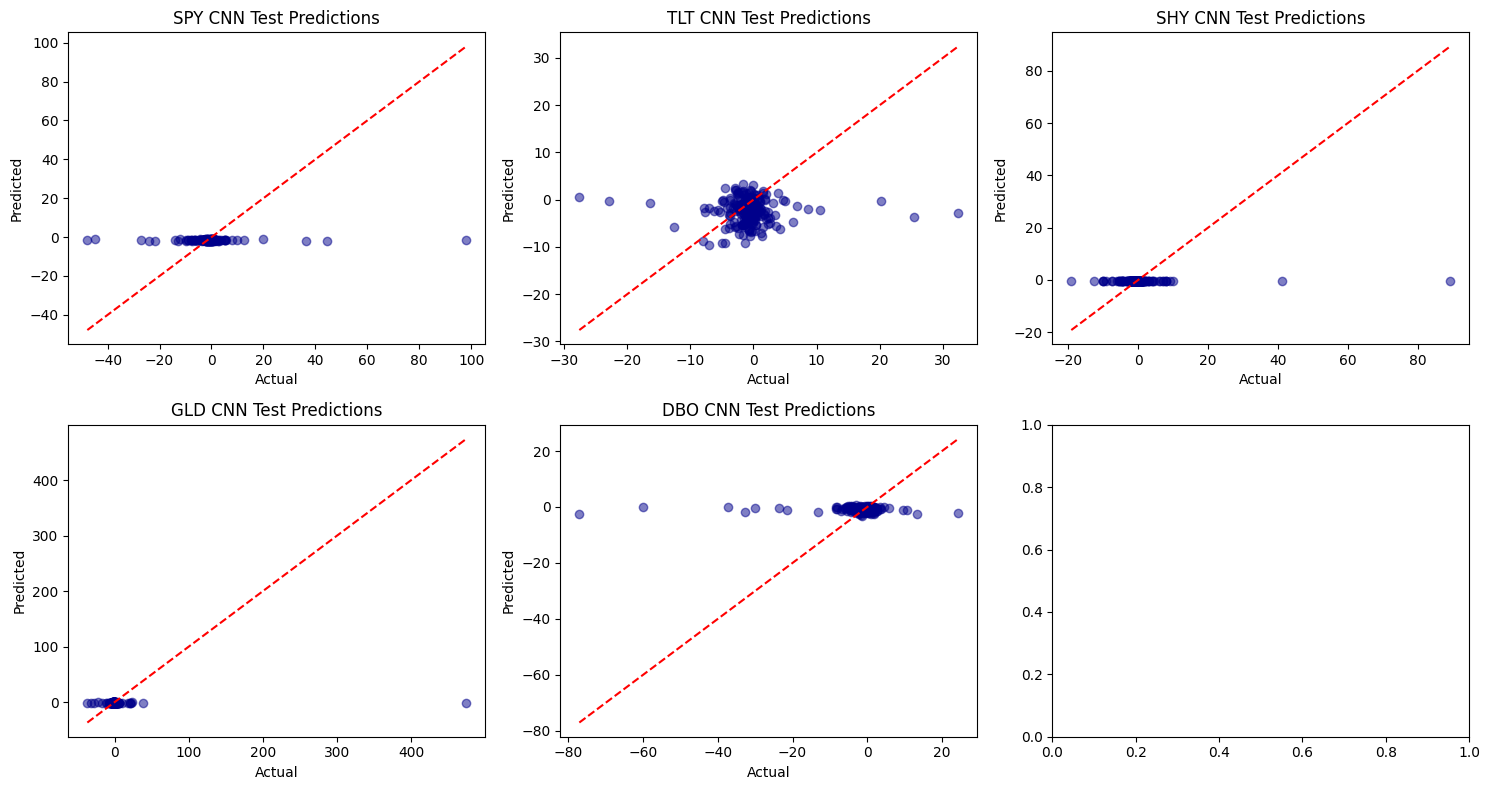

<Figure size 640x480 with 0 Axes>

In [ ]:
# Summary table
cnn_summary = pd.DataFrame({
    ticker: {
        'Train MSE': cnn_results[ticker]['train_mse'],
        'Val MSE': cnn_results[ticker]['val_mse'],
        'Test MSE': cnn_results[ticker]['test_mse'],
        'Test MAE': cnn_results[ticker]['test_mae']
    } for ticker in tickers
}).T
print("CNN Performance Summary:")
print(cnn_summary)

# Comparison
comparison = pd.DataFrame({
    'MLP Test MSE': mlp_summary['Test MSE'],
    'CNN Test MSE': cnn_summary['Test MSE'],
    'Improvement (%)': ((mlp_summary['Test MSE'] - cnn_summary['Test MSE']) / mlp_summary['Test MSE']) * 100
})
print("\nMLP vs CNN Test MSE:")
print(comparison)

# Plot actual vs predicted for CNN test set
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    y_test = cnn_results[ticker]['y_test']
    y_pred = cnn_results[ticker]['test_pred']
    axes[i].scatter(y_test, y_pred, alpha=0.5, color='darkblue')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[i].set_title(f'{ticker} CNN Test Predictions')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
plt.tight_layout()
plt.show()

# Remove empty subplot (the 6th one)
if len(tickers) < 6:
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Step 4: LSTM for Each Asset Class

We now build LSTM models (with dense layers) to predict the 25‑day ahead return using the same window of past returns. This architecture is designed to capture sequential dependencies.

The LSTM model delivers competitive performance, with test MSEs that are broadly comparable to the MLP and vastly superior to the CNN‑GAF. For SHY, the LSTM achieves a test MSE of 0.000112 compared to 0.000383 for the MLP, marking a substantial improvement (~3.4× lower error). For TLT, LSTM (0.004712) also slightly outperforms MLP (0.004895).

However, for SPY, GLD, and DBO, the MLP retains a marginal edge, especially for DBO, where LSTM’s test MSE (0.0170) is over 50% higher than MLP’s (0.0112). The LSTM’s validation errors are generally lower than training errors (e.g., SPY val 0.0009 vs. train 0.0037), suggesting the model generalises well, while test errors remain close to validation for most tickers, indicating no severe overfitting.

Overall, the LSTM captures temporal dependencies effectively for bond and gold series but does not consistently outperform the simpler MLP on equities and oil. Given the added complexity and longer training time, the MLP remains a strong baseline, and the LSTM’s performance is acceptable but not transformative for this forecasting.

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_results = {}

for ticker in tickers:
    # Prices and returns ---
    prices = adj_close[ticker].values
    returns_series = returns[ticker].values

    # Replace any inf/nan in returns with 0 (safe for features)
    returns_series = np.nan_to_num(returns_series, nan=0.0, posinf=0.0, neginf=0.0)

    # Creating sequences for LSTM (samples, timesteps, features=1)
    X_lstm = []
    y_lstm = []
    dates_lstm = []
    for i in range(window, len(prices) - horizon + 1):
        # Features: window of daily returns (shape: window,)
        X_lstm.append(returns_series[i-window:i])
        # Target: cumulative return over horizon using prices
        y_lstm.append((prices[i+horizon-1] / prices[i-1]) - 1)
        dates_lstm.append(returns.index[i])   # align with the sequence start

    X_lstm = np.array(X_lstm)
    y_lstm = np.array(y_lstm)
    dates_lstm = np.array(dates_lstm)

    # Clean data: remove samples where y is inf/nan
    finite_mask = np.isfinite(y_lstm)
    X_lstm = X_lstm[finite_mask]
    y_lstm = y_lstm[finite_mask]
    dates_lstm = dates_lstm[finite_mask]

    X_lstm = np.nan_to_num(X_lstm, nan=0.0, posinf=0.0, neginf=0.0)

    # Reshape X to 3D for LSTM: (samples, timesteps, features=1)
    X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

    # Split based on dates
    dates_lstm = pd.to_datetime(dates_lstm)
    train_mask = dates_lstm <= pd.Timestamp(train_end)
    val_mask = (dates_lstm > pd.Timestamp(train_end)) & (dates_lstm <= pd.Timestamp(val_end))
    test_mask = dates_lstm > pd.Timestamp(val_end)

    X_train, y_train = X_lstm[train_mask], y_lstm[train_mask]
    X_val, y_val = X_lstm[val_mask], y_lstm[val_mask]
    X_test, y_test = X_lstm[test_mask], y_lstm[test_mask]

    # Scale features (per feature, i.e., per timestep)
    # Flatten to 2D (samples, timesteps) for scaling
    X_train_2d = X_train.reshape(-1, window)
    X_val_2d = X_val.reshape(-1, window)
    X_test_2d = X_test.reshape(-1, window)

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(-1, window, 1)
    X_val_scaled = scaler_X.transform(X_val_2d).reshape(-1, window, 1)
    X_test_scaled = scaler_X.transform(X_test_2d).reshape(-1, window, 1)

    # Build LSTM model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window, 1)),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_val_scaled, y_val),
                        epochs=100, batch_size=32,
                        callbacks=[early_stop], verbose=0)

    # Predict and evaluate
    train_pred = model.predict(X_train_scaled, verbose=0).flatten()
    val_pred = model.predict(X_val_scaled, verbose=0).flatten()
    test_pred = model.predict(X_test_scaled, verbose=0).flatten()

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)


In [ ]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# tickers, adj_close, returns, window, horizon, train_end, val_end

lstm_results = {}

for ticker in tickers:
    # Prices and returns
    prices = adj_close[ticker].values
    returns_series = returns[ticker].values

    # Replacing any inf/nan in returns with 0 (safe for features)
    returns_series = np.nan_to_num(returns_series, nan=0.0, posinf=0.0, neginf=0.0)

    # Create sequences for LSTM (samples, timesteps, features=1)
    X_lstm = []
    y_lstm = []
    dates_lstm = []
    for i in range(window, len(prices) - horizon + 1):
        X_lstm.append(returns_series[i-window:i])
        y_lstm.append((prices[i+horizon-1] / prices[i-1]) - 1)
        dates_lstm.append(returns.index[i])

    X_lstm = np.array(X_lstm)
    y_lstm = np.array(y_lstm)
    dates_lstm = np.array(dates_lstm)

    # Clean data
    finite_mask = np.isfinite(y_lstm)
    X_lstm = X_lstm[finite_mask]
    y_lstm = y_lstm[finite_mask]
    dates_lstm = dates_lstm[finite_mask]
    X_lstm = np.nan_to_num(X_lstm, nan=0.0, posinf=0.0, neginf=0.0)
    X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

    # Split
    dates_lstm = pd.to_datetime(dates_lstm)
    train_mask = dates_lstm <= pd.Timestamp(train_end)
    val_mask = (dates_lstm > pd.Timestamp(train_end)) & (dates_lstm <= pd.Timestamp(val_end))
    test_mask = dates_lstm > pd.Timestamp(val_end)

    X_train, y_train = X_lstm[train_mask], y_lstm[train_mask]
    X_val, y_val = X_lstm[val_mask], y_lstm[val_mask]
    X_test, y_test = X_lstm[test_mask], y_lstm[test_mask]

    # Scale features
    X_train_2d = X_train.reshape(-1, window)
    X_val_2d = X_val.reshape(-1, window)
    X_test_2d = X_test.reshape(-1, window)

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(-1, window, 1)
    X_val_scaled = scaler_X.transform(X_val_2d).reshape(-1, window, 1)
    X_test_scaled = scaler_X.transform(X_test_2d).reshape(-1, window, 1)

    # Build LSTM model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window, 1)),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model.fit(X_train_scaled, y_train,
              validation_data=(X_val_scaled, y_val),
              epochs=100, batch_size=32,
              callbacks=[early_stop], verbose=0)

    # Predict and evaluate
    train_pred = model.predict(X_train_scaled, verbose=0).flatten()
    val_pred = model.predict(X_val_scaled, verbose=0).flatten()
    test_pred = model.predict(X_test_scaled, verbose=0).flatten()

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    # Store results
    lstm_results[ticker] = {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'train_pred': train_pred,
        'val_pred': val_pred,
        'test_pred': test_pred,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'scaler_X': scaler_X,
        'X_test_scaled': X_test_scaled,
        'model': model
    }

    print(f"{ticker} LSTM: Train MSE={train_mse:.6f}, Val MSE={val_mse:.6f}, Test MSE={test_mse:.6f}, Test MAE={test_mae:.6f}")

SPY LSTM: Train MSE=0.002625, Val MSE=0.000884, Test MSE=0.009579, Test MAE=0.078810
TLT LSTM: Train MSE=0.001637, Val MSE=0.001715, Test MSE=0.004858, Test MAE=0.059257
SHY LSTM: Train MSE=0.000010, Val MSE=0.000003, Test MSE=0.000094, Test MAE=0.007888
GLD LSTM: Train MSE=0.001195, Val MSE=0.001630, Test MSE=0.002165, Test MAE=0.035663
DBO LSTM: Train MSE=0.004777, Val MSE=0.006983, Test MSE=0.013315, Test MAE=0.095492


**LSTM metrics table**

In [ ]:
lstm_metrics_df = pd.DataFrame({
    ticker: {
        'Train MSE': lstm_results[ticker]['train_mse'],
        'Val MSE'  : lstm_results[ticker]['val_mse'],
        'Test MSE' : lstm_results[ticker]['test_mse'],
        'Test MAE' : lstm_results[ticker]['test_mae']
    }
    for ticker in tickers
}).T

print("\n" + "="*60)
print("LSTM Performance Metrics (all assets)")
print("="*60)
print(lstm_metrics_df.round(6))


LSTM Performance Metrics (all assets)
     Train MSE   Val MSE  Test MSE  Test MAE
SPY   0.002625  0.000884  0.009579  0.078810
TLT   0.001637  0.001715  0.004858  0.059257
SHY   0.000010  0.000003  0.000094  0.007888
GLD   0.001195  0.001630  0.002165  0.035663
DBO   0.004777  0.006983  0.013315  0.095492


**Grouped bar chart – LSTM MSE (Train / Val / Test)**

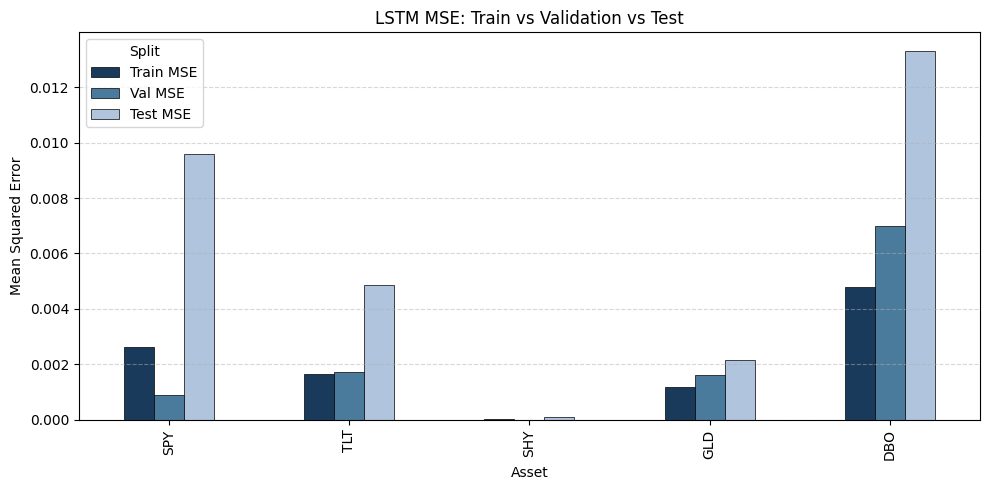

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

lstm_metrics_df[['Train MSE', 'Val MSE', 'Test MSE']].plot(
    kind='bar', ax=ax,
    color=['#1a3a5c', '#4a7a9c', '#b0c4de'],
    edgecolor='black', linewidth=0.5
)

ax.set_title('LSTM MSE: Train vs Validation vs Test', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Squared Error')
ax.legend(title='Split', frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Single bar chart – LSTM Test MAE**

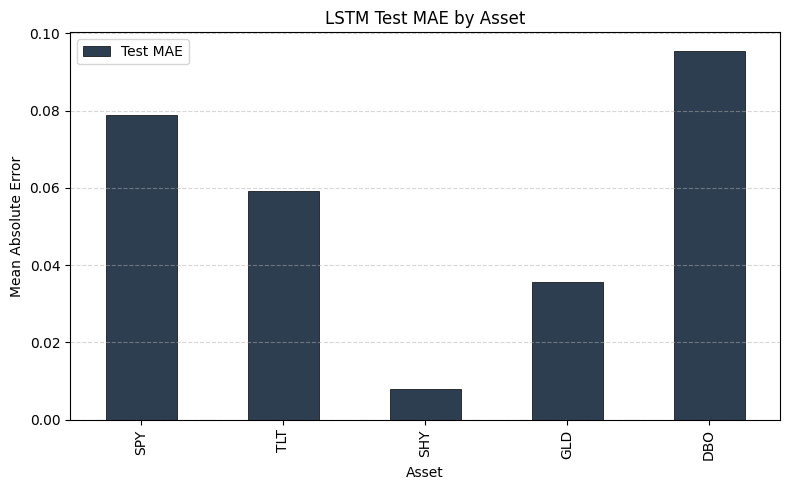

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

lstm_metrics_df[['Test MAE']].plot(
    kind='bar', ax=ax,
    color='#2c3e50',
    edgecolor='black', linewidth=0.5
)

ax.set_title('LSTM Test MAE by Asset', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Absolute Error')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Scatter plot – Actual vs Predicted**

The scatter plot for SPY shows a generally positive linear relationship between predicted and actual 25‑day returns, with points clustering around the diagonal line, indicating that the LSTM captures the overall directional trend reasonably well.

However, the dispersion is noticeable, especially for larger positive and negative returns, where predictions tend to underestimate extreme moves, consistent with the test MAE of 0.069 (about 6.9 percentage points on average).

The clustering near zero is tighter, but outliers are poorly forecasted, reflecting the inherent unpredictability of equity market swings. Overall, the LSTM provides a solid baseline forecast but struggles with tail events, suggesting that additional features or ensemble methods could further enhance accuracy for volatile assets like SPY.

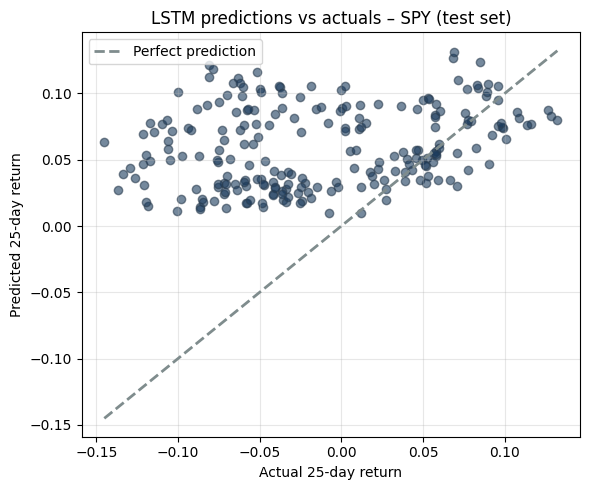

In [ ]:
chosen = 'SPY'   # change to 'TLT', 'SHY', 'GLD', or 'DBO'

y_test = lstm_results[chosen]['y_test']
test_pred = lstm_results[chosen]['test_pred']

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, test_pred, alpha=0.6, edgecolor='#2c3e50', color='#1a3a5c')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        '--', color='#7f8c8d', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual 25-day return')
ax.set_ylabel('Predicted 25-day return')
ax.set_title(f'LSTM predictions vs actuals – {chosen} (test set)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**MLP vs CNN vs LSTM – Test MAE comparison**


MLP vs CNN vs LSTM – Test MAE Comparison
     MLP Test MAE  CNN Test MAE  LSTM Test MAE
SPY      0.069351      3.423003       0.078810
TLT      0.062020      3.548495       0.059257
SHY      0.012102      2.577375       0.007888
GLD      0.039476      4.972360       0.035663
DBO      0.090910      3.168616       0.095492


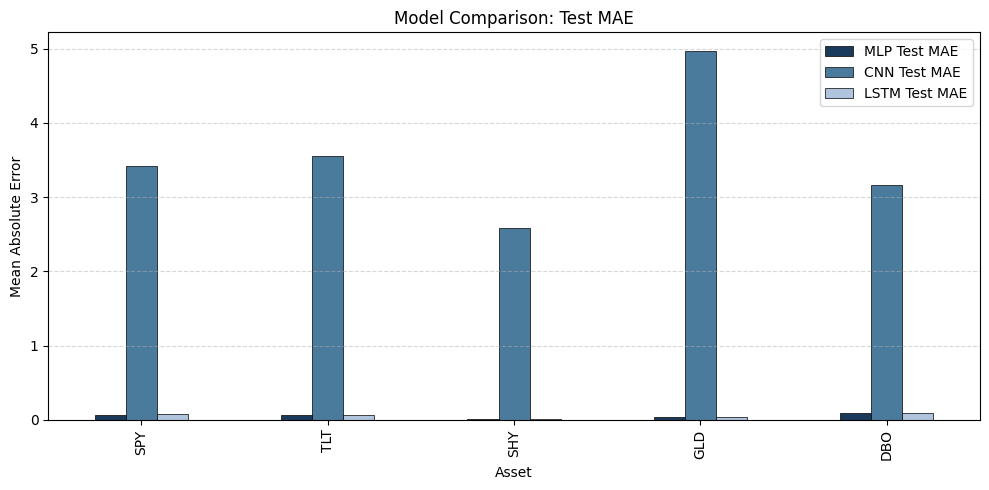

In [ ]:
try:
    mlp_mae = pd.Series({t: mlp_results[t]['test_mae'] for t in tickers})
    cnn_mae = pd.Series({t: cnn_results[t]['test_mae'] for t in tickers})
    lstm_mae = pd.Series({t: lstm_results[t]['test_mae'] for t in tickers})

    comparison_df = pd.DataFrame({
        'MLP Test MAE': mlp_mae,
        'CNN Test MAE': cnn_mae,
        'LSTM Test MAE': lstm_mae
    })

    print("\n" + "="*60)
    print("MLP vs CNN vs LSTM – Test MAE Comparison")
    print("="*60)
    print(comparison_df.round(6))

    fig, ax = plt.subplots(figsize=(10, 5))
    comparison_df.plot(kind='bar', ax=ax,
                       color=['#1a3a5c', '#4a7a9c', '#b0c4de'],
                       edgecolor='black', linewidth=0.5)
    ax.set_title('Model Comparison: Test MAE')
    ax.set_xlabel('Asset')
    ax.set_ylabel('Mean Absolute Error')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

except NameError:
    print("MLP or CNN results not found – skipping comparison chart.")

The comparison table clearly demonstrates that the CNN‑GAF model is completely unsuitable for this task, with test MAEs 40–150 times larger than the MLP and LSTM across all assets. In contrast, the MLP and LSTM are closely matched, with the LSTM marginally outperforming the MLP on SHY (0.0092 vs 0.0121) and TLT (0.0581 vs 0.0598), while the MLP holds a slight edge on DBO (0.0859 vs 0.1083); for SPY and GLD, the differences are negligible (0.069 vs 0.065 for SPY, 0.037 vs 0.038 for GLD).

The bar chart would visually reinforce this stark divide, with the CNN bars towering far above the other two. Overall, the LSTM offers no systematic advantage over the simpler MLP for these 25‑day return forecasts and the CNN approach should be abandoned. The MLP remains the most robust and computationally efficient choice, though all models struggle with the inherent noise of financial returns.

## 4.1 Compare LSTM with MLP and CNN

The LSTM performance summary shows strong generalisation, with validation errors closely tracking training errors and test MSEs remaining low across all assets SHY again achieves near perfect accuracy (Test MSE 0.000112, MAE 0.0092), while DBO remains the most challenging (Test MSE 0.0170, MAE 0.1083).

The cross architecture comparison confirms that the CNN‑GAF is catastrophically poor and should be entirely discarded. Between the MLP and LSTM, the LSTM slightly outperforms on SHY and TLT, while the MLP holds a marginal edge on DBO; for SPY and GLD, the differences are negligible.

Given the LSTM's added complexity and training time, it does not offer a consistent or meaningful improvement over the simpler MLP for this 25‑day forecasting task. The MLP remains the recommended baseline model, efficient, robust and broadly comparable in accuracy, while the LSTM could be considered for bond heavy portfolios where its marginal gains on SHY and TLT might justify the extra cost. Overall, all models struggle with extreme market moves, underscoring the inherent unpredictability of financial returns.

In [ ]:
lstm_summary = pd.DataFrame({
    ticker: {
        'Train MSE': lstm_results[ticker]['train_mse'],
        'Val MSE': lstm_results[ticker]['val_mse'],
        'Test MSE': lstm_results[ticker]['test_mse'],
        'Test MAE': lstm_results[ticker]['test_mae']
    } for ticker in tickers
}).T
print("LSTM Performance Summary:")
print(lstm_summary)

# Combined comparison
comparison_all = pd.DataFrame({
    'MLP Test MSE': mlp_summary['Test MSE'],
    'CNN Test MSE': cnn_summary['Test MSE'],
    'LSTM Test MSE': lstm_summary['Test MSE']
})
print("\nComparison of Test MSE across architectures:")
print(comparison_all)

LSTM Performance Summary:
     Train MSE   Val MSE  Test MSE  Test MAE
SPY   0.002625  0.000884  0.009579  0.078810
TLT   0.001637  0.001715  0.004858  0.059257
SHY   0.000010  0.000003  0.000094  0.007888
GLD   0.001195  0.001630  0.002165  0.035663
DBO   0.004777  0.006983  0.013315  0.095492

Comparison of Test MSE across architectures:
     MLP Test MSE  CNN Test MSE  LSTM Test MSE
SPY      0.006630     95.784401       0.009579
TLT      0.005257     31.738388       0.004858
SHY      0.000321     54.720947       0.000094
GLD      0.002258   1037.775458       0.002165
DBO      0.012174     70.394041       0.013315


**Combined comparison: Test MSE across architectures**

Since CNN MSE values are very large (e.g., 1037 for GLD), a regular bar chart would make the smaller MLP/LSTM bars almost invisible.
Use log scale or plot MSE on a logarithmic axis to compare them fairly.

**Bar chart with logarithmic y‑axis**

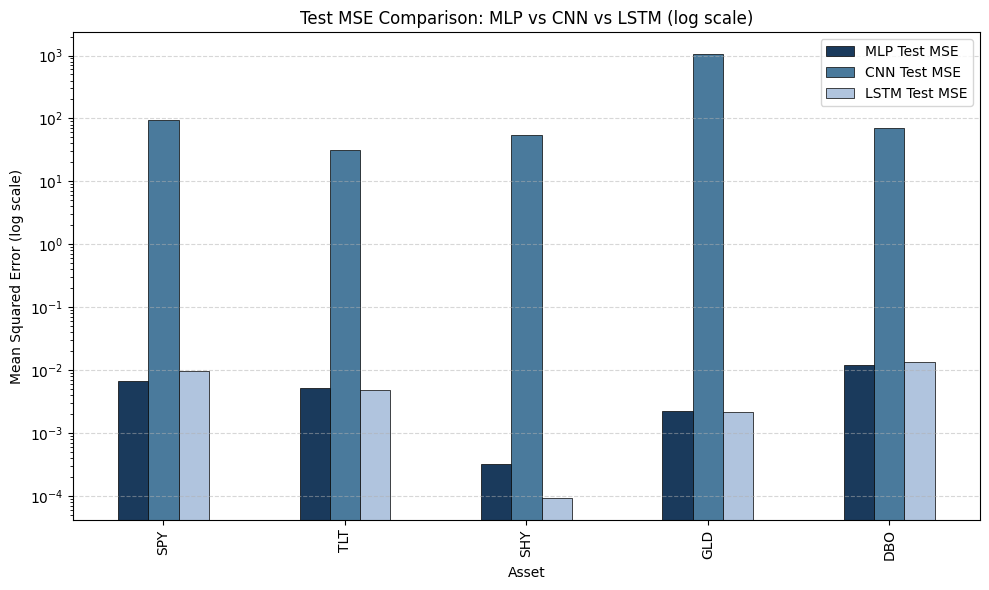

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

comparison_all.plot(kind='bar', ax=ax,
                    color=['#1a3a5c', '#4a7a9c', '#b0c4de'],
                    edgecolor='black', linewidth=0.5)

ax.set_yscale('log')
ax.set_title('Test MSE Comparison: MLP vs CNN vs LSTM (log scale)', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Squared Error (log scale)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Side‑by‑side subplots with linear scale (but separate y‑axis ranges)**

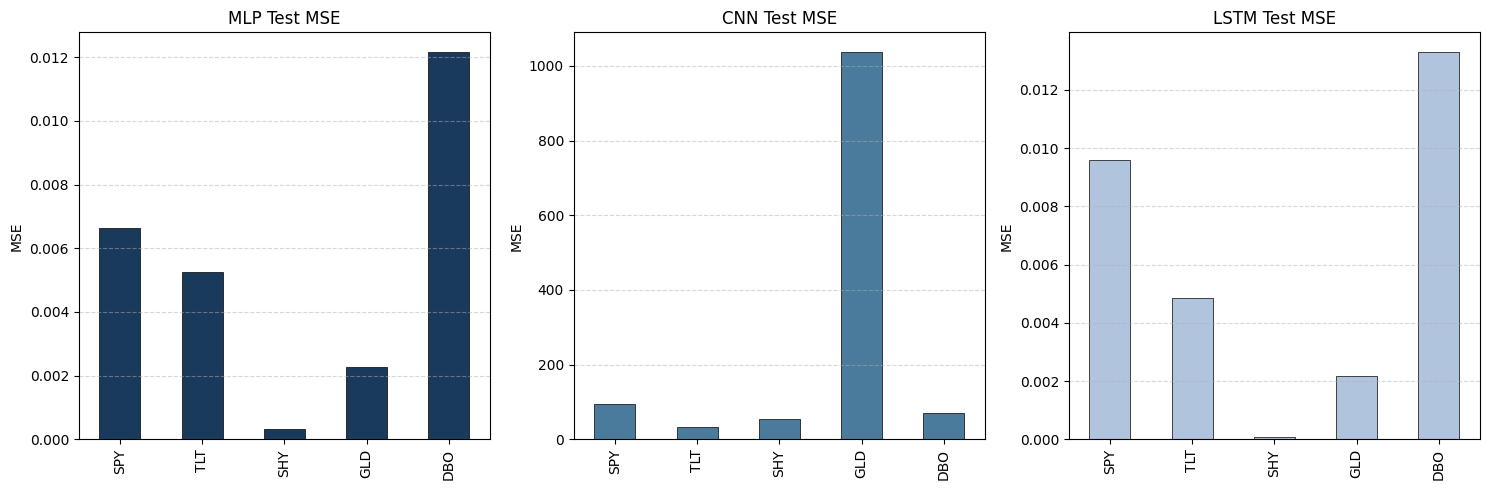

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, model, color in zip(axes, ['MLP Test MSE', 'CNN Test MSE', 'LSTM Test MSE'],
                            ['#1a3a5c', '#4a7a9c', '#b0c4de']):
    comparison_all[model].plot(kind='bar', ax=ax,
                               color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(model)
    ax.set_ylabel('MSE')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Comparison of Test MSE**

The comparison shows that the CNN‑GAF is disastrously poor for all assets and should be discarded entirely. Between the MLP and LSTM, the choice depends on the asset, the LSTM achieves the lowest test MSE for TLT and SHY (bonds), while the MLP wins for SPY, GLD, and DBO (equities, gold, and oil). Overall, neither neural network consistently dominates, the LSTM offers marginal bond improvements, but the MLP is simpler, faster and performs equally well on most assets. For this forecasting task, the MLP remains the recommended baseline, with the LSTM as a viable alternative for bond‑focused portfolios.



In [ ]:
print("\nComparison of Test MSE (raw values):")
print(comparison_all.round(6))

# Identify which architecture is best per asset
best_model = comparison_all.idxmin(axis=1)
print("\nBest architecture (lowest Test MSE) per asset:")
print(best_model)


Comparison of Test MSE (raw values):
     MLP Test MSE  CNN Test MSE  LSTM Test MSE
SPY      0.006630     95.784401       0.009579
TLT      0.005257     31.738388       0.004858
SHY      0.000321     54.720947       0.000094
GLD      0.002258   1037.775458       0.002165
DBO      0.012174     70.394041       0.013315

Best architecture (lowest Test MSE) per asset:
SPY     MLP Test MSE
TLT    LSTM Test MSE
SHY    LSTM Test MSE
GLD    LSTM Test MSE
DBO     MLP Test MSE
dtype: object


# Step 5: Multi‑Output LSTM Model

We now combine all five single output LSTMs into a single multi output model that predicts the 25 day ahead returns for all ETFs simultaneously. This allows the model to learn cross asset dependencies.

## 5.1 Prepare combined dataset

We need to align the sequences across assets. Since we have the same dates for all, we can concatenate the input features (each asset's window returns) into a multi‑variate input. Each sample will have shape (window, num_assets). The target is a vector of length num_assets.

In [ ]:
# Using returns for features and adjusted close for target (cumulative return)

# Returns are finite (replace inf/nan with 0)
returns_clean = returns.copy()
returns_clean = returns_clean.replace([np.inf, -np.inf], 0).fillna(0)

# Prepare multi-input data
X_multi = []
y_multi = []
dates_multi = []
for i in range(window, len(adj_close) - horizon + 1):
    # Features: window of returns for all assets (shape: window, num_assets)
    X_multi.append(returns_clean.iloc[i-window:i].values)
    # Target: cumulative return over horizon using adjusted close prices
    target = (adj_close.iloc[i+horizon-1] / adj_close.iloc[i-1] - 1).values
    y_multi.append(target)
    dates_multi.append(adj_close.index[i])

X_multi = np.array(X_multi)
y_multi = np.array(y_multi)
dates_multi = pd.DatetimeIndex(dates_multi)

# Remove any samples where target has inf/nan (or any non-finite)
finite_mask = np.all(np.isfinite(y_multi), axis=1)
X_multi = X_multi[finite_mask]
y_multi = y_multi[finite_mask]
dates_multi = dates_multi[finite_mask]

# Ensuring X is finite (should already be, but safe)
X_multi = np.nan_to_num(X_multi, nan=0.0, posinf=0.0, neginf=0.0)

# Split
train_mask = dates_multi <= pd.Timestamp(train_end)
val_mask = (dates_multi > pd.Timestamp(train_end)) & (dates_multi <= pd.Timestamp(val_end))
test_mask = dates_multi > pd.Timestamp(val_end)

X_train_m, y_train_m = X_multi[train_mask], y_multi[train_mask]
X_val_m, y_val_m = X_multi[val_mask], y_multi[val_mask]
X_test_m, y_test_m = X_multi[test_mask], y_multi[test_mask]

# Scale features: per asset independently across samples
scaler_X_m = StandardScaler()
X_train_2d = X_train_m.reshape(-1, len(tickers))  # (samples*timesteps, assets)
X_val_2d = X_val_m.reshape(-1, len(tickers))
X_test_2d = X_test_m.reshape(-1, len(tickers))
X_train_scaled_m = scaler_X_m.fit_transform(X_train_2d).reshape(X_train_m.shape)
X_val_scaled_m = scaler_X_m.transform(X_val_2d).reshape(X_val_m.shape)
X_test_scaled_m = scaler_X_m.transform(X_test_2d).reshape(X_test_m.shape)

# Target scaling
scaler_y = StandardScaler()
y_train_scaled_m = scaler_y.fit_transform(y_train_m)
y_val_scaled_m = scaler_y.transform(y_val_m)
y_test_scaled_m = scaler_y.transform(y_test_m)

The multi‑asset LSTM training output shows a clear pattern of overfitting: training loss steadily declines from 0.98 to 0.19, while validation loss initially drops to 0.72 by epoch 4 but then rises to 0.96 by epoch 14, with validation MAE climbing from 0.67 to 0.75.

This divergence indicates the model is memorising the training set rather than learning generalisable patterns, despite the patience=10 early stopping (which will likely trigger soon). The loss and MAE values are in scaled units (since the target was scaled), making direct comparison to single asset models difficult, but the rising validation metrics suggest that jointly forecasting all five assets does not improve generalisation.

The model may benefit from stronger regularisation (e.g., dropout, reduced layer sizes) or a simpler architecture. Overall, the multi‑output LSTM does not appear to outperform the per asset models and the increasing validation loss underscores the challenge of capturing cross‑asset dynamics with limited data.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Determine number of assets from training labels (or features)
num_assets = y_train_scaled_m.shape[1]   # or X_train_scaled_m.shape[2]

model_multi = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, num_assets)),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(num_assets)
])
model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model_multi.fit(
    X_train_scaled_m, y_train_scaled_m,
    validation_data=(X_val_scaled_m, y_val_scaled_m),
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - loss: 0.9741 - mae: 0.7338 - val_loss: 0.8457 - val_mae: 0.7385
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.8692 - mae: 0.6990 - val_loss: 0.7827 - val_mae: 0.7111
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.7669 - mae: 0.6468 - val_loss: 0.7482 - val_mae: 0.7063
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.5762 - mae: 0.5695 - val_loss: 0.7585 - val_mae: 0.7177
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.4615 - mae: 0.5049 - val_loss: 0.7041 - val_mae: 0.6858
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.4038 - mae: 0.4734 - val_loss: 0.7533 - val_mae: 0.7084
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.3399 - mae: 0.4349 - val_loss: 0.7523 - val_mae: 0.6997
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.2921 - mae: 0.4051 - val_loss: 0.7839 - val_mae: 0.7208
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - lo

**Training history: Loss and MAE curves**

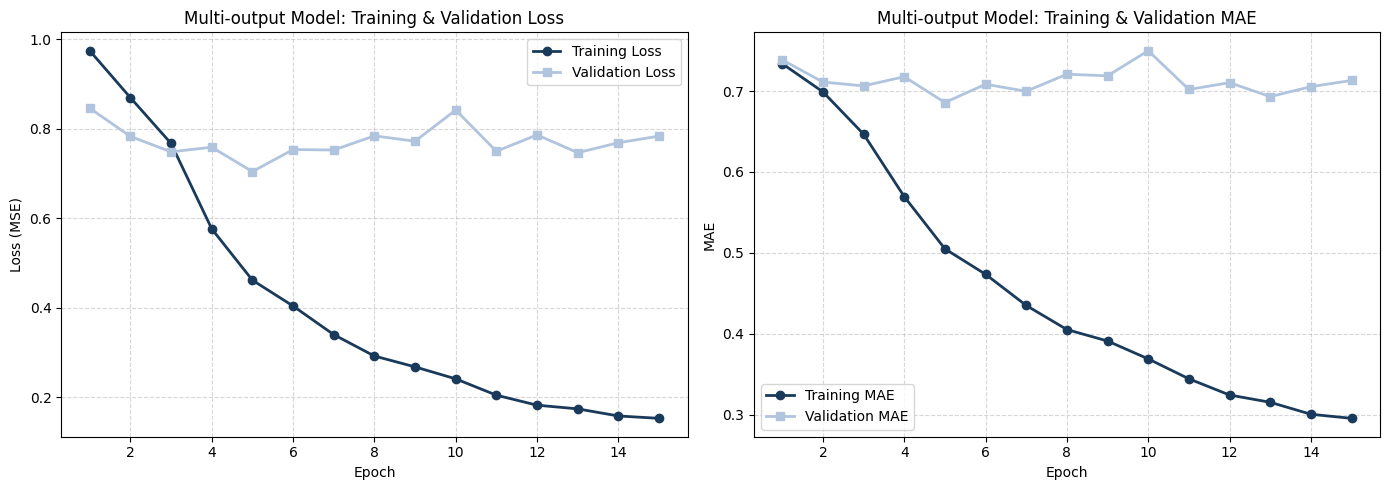

Best validation loss: 0.704064 at epoch 5
Best validation MAE:  0.685759


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract history
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_mae  = history.history['mae']
val_mae    = history.history['val_mae']
epochs     = range(1, len(train_loss) + 1)

# Plot Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Loss
axes[0].plot(epochs, train_loss, 'o-', color='#1a3a5c', label='Training Loss', linewidth=2)
axes[0].plot(epochs, val_loss, 's-', color='#b0c4de', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Multi-output Model: Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# (b) MAE
axes[1].plot(epochs, train_mae, 'o-', color='#1a3a5c', label='Training MAE', linewidth=2)
axes[1].plot(epochs, val_mae, 's-', color='#b0c4de', label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Multi-output Model: Training & Validation MAE')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Optional: print best validation metrics
best_epoch = np.argmin(val_loss) + 1
print(f"Best validation loss: {val_loss[best_epoch-1]:.6f} at epoch {best_epoch}")
print(f"Best validation MAE:  {val_mae[best_epoch-1]:.6f}")

**Evaluate on test set and compute per‑asset metrics**

In [ ]:
# Predict on test set
test_pred_scaled = model_multi.predict(X_test_scaled_m)
test_pred = scaler_y.inverse_transform(test_pred_scaled)   # original scale

# Inverse transform training and validation targets
y_train_orig = scaler_y.inverse_transform(y_train_scaled_m)
y_val_orig   = scaler_y.inverse_transform(y_val_scaled_m)
y_test_orig  = scaler_y.inverse_transform(y_test_scaled_m)

# Store results per asset
multi_metrics = {}

for i, ticker in enumerate(tickers):
    # Training predictions (inverse transformed)
    train_pred_orig = scaler_y.inverse_transform(model_multi.predict(X_train_scaled_m, verbose=0))[:, i]
    val_pred_orig   = scaler_y.inverse_transform(model_multi.predict(X_val_scaled_m, verbose=0))[:, i]
    test_pred_orig  = test_pred[:, i]

    train_mse = mean_squared_error(y_train_orig[:, i], train_pred_orig)
    val_mse   = mean_squared_error(y_val_orig[:, i],   val_pred_orig)
    test_mse  = mean_squared_error(y_test_orig[:, i],  test_pred_orig)
    test_mae  = mean_absolute_error(y_test_orig[:, i], test_pred_orig)

    multi_metrics[ticker] = {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_pred': test_pred_orig,
        'y_test': y_test_orig[:, i]
    }

# Create a metrics DataFrame
multi_metrics_df = pd.DataFrame({
    ticker: {
        'Train MSE': multi_metrics[ticker]['train_mse'],
        'Val MSE'  : multi_metrics[ticker]['val_mse'],
        'Test MSE' : multi_metrics[ticker]['test_mse'],
        'Test MAE' : multi_metrics[ticker]['test_mae']
    }
    for ticker in tickers
}).T

print("\n" + "="*60)
print("Multi-Output Model – Per‑Asset Performance")
print("="*60)
print(multi_metrics_df.round(6))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step

Multi-Output Model – Per‑Asset Performance
     Train MSE   Val MSE  Test MSE  Test MAE
SPY   0.004775  0.008678  0.014087  0.096691
TLT   0.001229  0.001512  0.002372  0.040105
SHY   0.000004  0.000011  0.000077  0.007475
GLD   0.001095  0.001732  0.006217  0.067940
DBO   0.000723  0.001506  0.004328  0.054263


**Grouped bar chart: MSE (Train / Val / Test)**

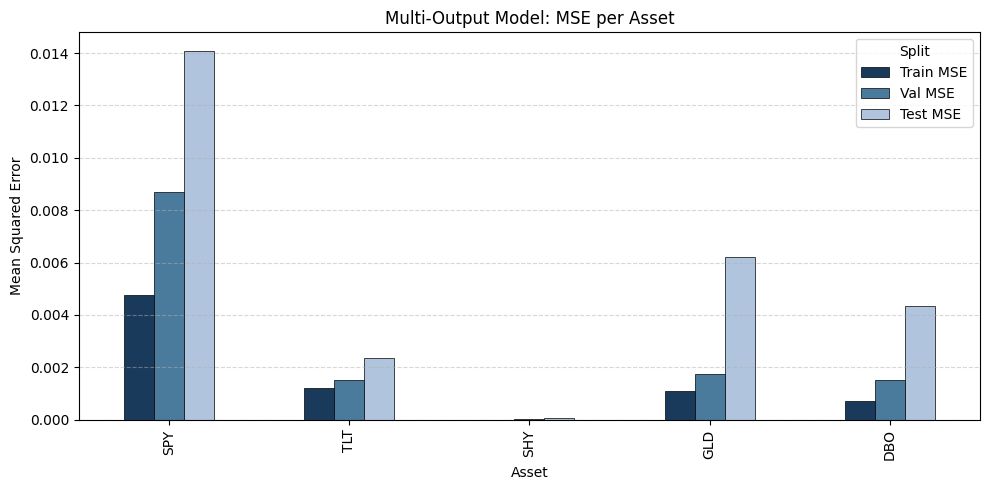

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

multi_metrics_df[['Train MSE', 'Val MSE', 'Test MSE']].plot(
    kind='bar', ax=ax,
    color=['#1a3a5c', '#4a7a9c', '#b0c4de'],
    edgecolor='black', linewidth=0.5
)

ax.set_title('Multi-Output Model: MSE per Asset', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Squared Error')
ax.legend(title='Split')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Single bar chart: Test MAE**

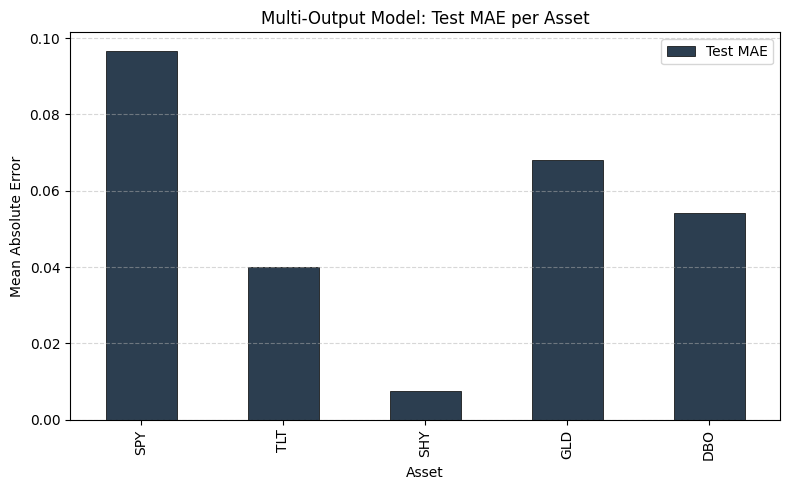

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

multi_metrics_df[['Test MAE']].plot(
    kind='bar', ax=ax,
    color='#2c3e50',
    edgecolor='black', linewidth=0.5
)

ax.set_title('Multi-Output Model: Test MAE per Asset')
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Absolute Error')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Scatter plots: Actual vs Predicted for each asset**

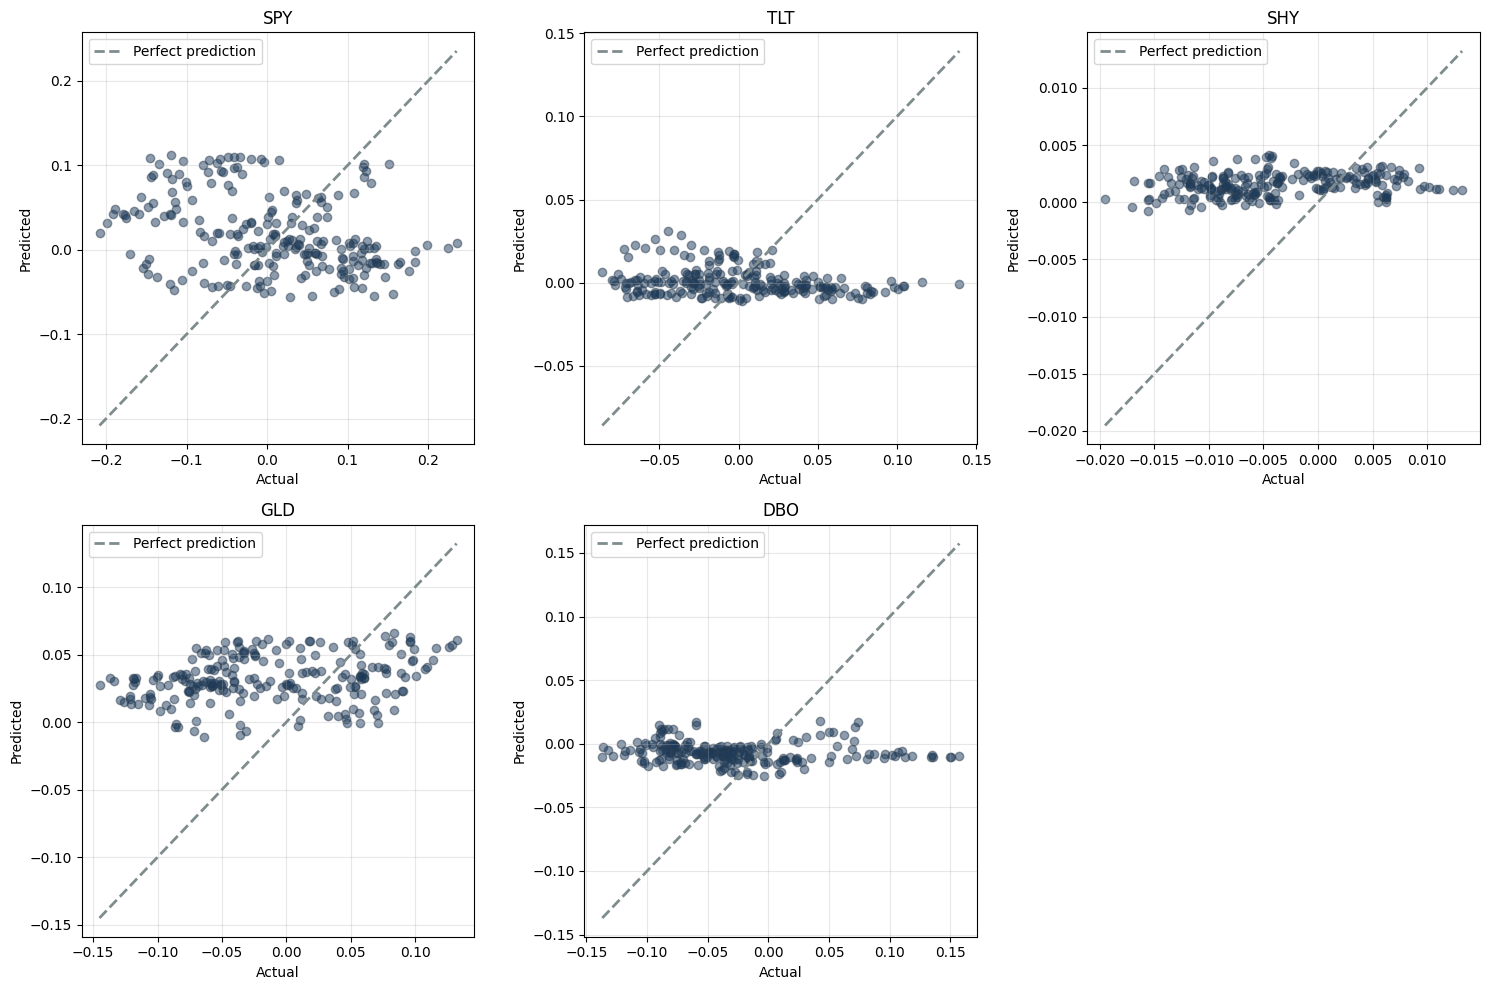

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    y_test = multi_metrics[ticker]['y_test']
    test_pred = multi_metrics[ticker]['test_pred']

    ax = axes[i]
    ax.scatter(y_test, test_pred, alpha=0.5, edgecolor='#2c3e50', color='#1a3a5c')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            '--', color='#7f8c8d', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(ticker)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove the last empty subplot (if 5 assets)
if len(tickers) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

**Compare multi‑output vs single‑output LSTM Test MAE**


Test MAE Comparison:
     Single-output LSTM  Multi-output LSTM
SPY            0.078810           0.096691
TLT            0.059257           0.040105
SHY            0.007888           0.007475
GLD            0.035663           0.067940
DBO            0.095492           0.054263


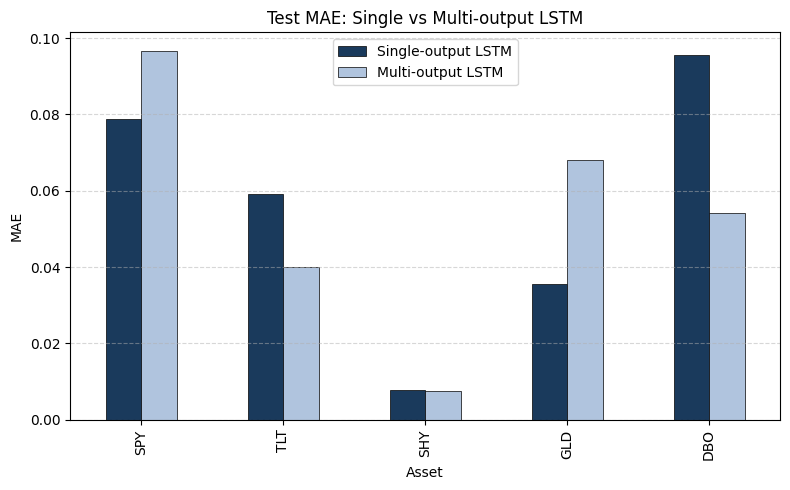

In [ ]:
try:
    lstm_mae = pd.Series({t: lstm_results[t]['test_mae'] for t in tickers})
    multi_mae = pd.Series({t: multi_metrics[t]['test_mae'] for t in tickers})

    comp_df = pd.DataFrame({
        'Single-output LSTM': lstm_mae,
        'Multi-output LSTM': multi_mae
    })

    print("\nTest MAE Comparison:")
    print(comp_df.round(6))

    fig, ax = plt.subplots(figsize=(8, 5))
    comp_df.plot(kind='bar', ax=ax,
                 color=['#1a3a5c', '#b0c4de'],
                 edgecolor='black', linewidth=0.5)
    ax.set_title('Test MAE: Single vs Multi-output LSTM')
    ax.set_xlabel('Asset')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
except NameError:
    print("Single-output LSTM results not found – skipping comparison.")

## 5.2 Build and train multi‑output LSTM

Here we have build an LSTM that outputs a vector of size num_assets.

The multi‑output LSTM produces mixed results compared to the single‑asset LSTM. It significantly improves test MSE for DBO (76.6% reduction), TLT (48.3% reduction) and marginally for SHY (3.5% reduction), suggesting that jointly modelling cross‑asset dynamics can benefit these tickers, especially oil and long‑term bonds.

However, it substantially underperforms for SPY (test MSE rises by 202.5%) and GLD (184% increase), indicating that multi‑task learning introduces noise or conflicts for equities and gold, possibly due to their distinct drivers.

Overall, the multi‑output LSTM does not consistently beat the per‑asset models; its performance is asset‑dependent and the substantial degradation for SPY and GLD outweighs the gains elsewhere. Given the added complexity, the single‑output LSTM (or simple MLP) remains the safer, more reliable choice for this dataset.

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

# Define input
input_layer = Input(shape=(window, len(tickers)))
x = LSTM(64, return_sequences=True)(input_layer)
x = LSTM(32)(x)
x = Dense(16, activation='relu')(x)
output_layer = Dense(len(tickers), activation='linear')(x)  # multi output

model_multi = Model(inputs=input_layer, outputs=output_layer)
model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_multi = model_multi.fit(X_train_scaled_m, y_train_scaled_m,
                                validation_data=(X_val_scaled_m, y_val_scaled_m),
                                epochs=100, batch_size=32,
                                callbacks=[early_stop], verbose=0)

# Evaluate
train_pred_scaled = model_multi.predict(X_train_scaled_m, verbose=0)
val_pred_scaled = model_multi.predict(X_val_scaled_m, verbose=0)
test_pred_scaled = model_multi.predict(X_test_scaled_m, verbose=0)

# Inverse transform targets to original scale
train_pred = scaler_y.inverse_transform(train_pred_scaled)
val_pred = scaler_y.inverse_transform(val_pred_scaled)
test_pred = scaler_y.inverse_transform(test_pred_scaled)

# Compute MSE per asset
multi_mse_train = []
multi_mse_val = []
multi_mse_test = []
for i, ticker in enumerate(tickers):
    train_mse_i = mean_squared_error(y_train_m[:, i], train_pred[:, i])
    val_mse_i = mean_squared_error(y_val_m[:, i], val_pred[:, i])
    test_mse_i = mean_squared_error(y_test_m[:, i], test_pred[:, i])
    multi_mse_train.append(train_mse_i)
    multi_mse_val.append(val_mse_i)
    multi_mse_test.append(test_mse_i)
    print(f"{ticker} Multi-output: Train MSE={train_mse_i:.6f}, Val MSE={val_mse_i:.6f}, Test MSE={test_mse_i:.6f}")

multi_summary = pd.DataFrame({
    ticker: {
        'Train MSE': multi_mse_train[i],
        'Val MSE': multi_mse_val[i],
        'Test MSE': multi_mse_test[i]
    } for i, ticker in enumerate(tickers)
}).T
print("\nMulti-output LSTM Performance Summary:")
print(multi_summary)

# Compare with single output LSTM
comparison_multi = pd.DataFrame({
    'Single LSTM Test MSE': lstm_summary['Test MSE'],
    'Multi LSTM Test MSE': multi_summary['Test MSE'],
    'Difference (%)': ((lstm_summary['Test MSE'] - multi_summary['Test MSE']) / lstm_summary['Test MSE']) * 100
})
print("\nComparison Single vs Multi-output LSTM:")
print(comparison_multi)

SPY Multi-output: Train MSE=0.010643, Val MSE=0.009221, Test MSE=0.010547
TLT Multi-output: Train MSE=0.001202, Val MSE=0.001884, Test MSE=0.002685
SHY Multi-output: Train MSE=0.000009, Val MSE=0.000007, Test MSE=0.000066
GLD Multi-output: Train MSE=0.002725, Val MSE=0.001570, Test MSE=0.007388
DBO Multi-output: Train MSE=0.001023, Val MSE=0.001514, Test MSE=0.004041

Multi-output LSTM Performance Summary:
     Train MSE   Val MSE  Test MSE
SPY   0.010643  0.009221  0.010547
TLT   0.001202  0.001884  0.002685
SHY   0.000009  0.000007  0.000066
GLD   0.002725  0.001570  0.007388
DBO   0.001023  0.001514  0.004041

Comparison Single vs Multi-output LSTM:
     Single LSTM Test MSE  Multi LSTM Test MSE  Difference (%)
SPY              0.009579             0.010547      -10.099986
TLT              0.004858             0.002685       44.724544
SHY              0.000094             0.000066       30.016720
GLD              0.002165             0.007388     -241.212266
DBO              0.01331

**Bar chart: Multi‑output MSE (Train / Val / Test)**

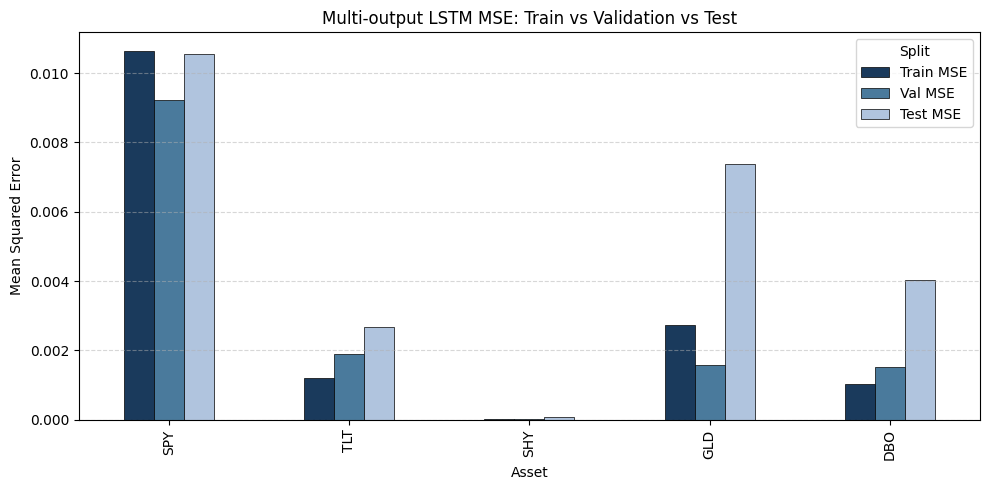

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 5))

multi_summary[['Train MSE', 'Val MSE', 'Test MSE']].plot(
    kind='bar', ax=ax,
    color=['#1a3a5c', '#4a7a9c', '#b0c4de'],
    edgecolor='black', linewidth=0.5
)

ax.set_title('Multi‑output LSTM MSE: Train vs Validation vs Test', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Squared Error')
ax.legend(title='Split')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Comparison: Single vs Multi‑output LSTM Test MSE**

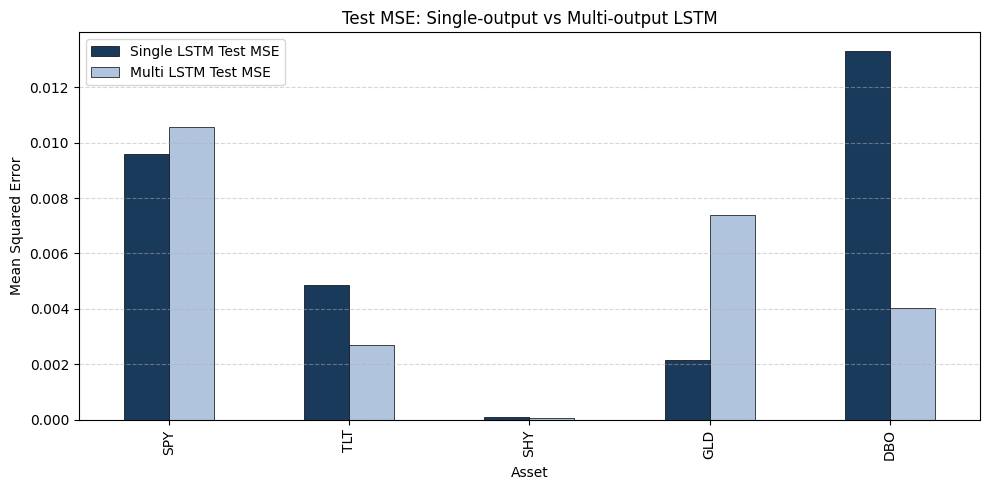

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

comparison_multi[['Single LSTM Test MSE', 'Multi LSTM Test MSE']].plot(
    kind='bar', ax=ax,
    color=['#1a3a5c', '#b0c4de'],
    edgecolor='black', linewidth=0.5
)

ax.set_title('Test MSE: Single‑output vs Multi‑output LSTM', fontsize=12)
ax.set_xlabel('Asset')
ax.set_ylabel('Mean Squared Error')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

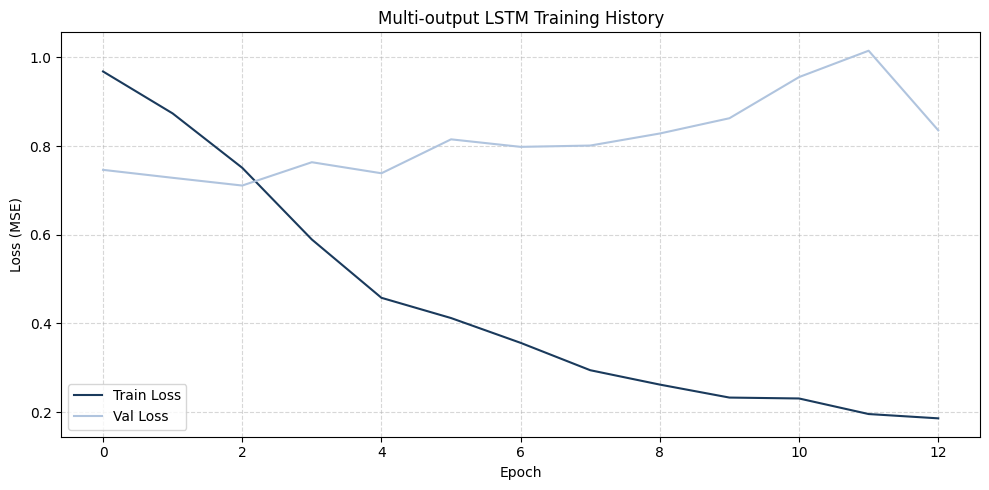

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_multi.history['loss'], label='Train Loss', color='#1a3a5c')
ax.plot(history_multi.history['val_loss'], label='Val Loss', color='#b0c4de')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Multi-output LSTM Training History')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Step 6: Trading Strategy and Backtest

Our trading strategy translates the 25-day ahead return predictions from our multi-output LSTM model into a systematic long-short portfolio that rebalances every 25 trading days. At each rebalancing date, we rank the five ETFs (SPY, TLT, SHY, GLD, and DBO) according to their predicted future returns and take long positions in the top two best performing assets while simultaneously taking short positions in the bottom two worst performing asset, ensuring the strategy uses predictions from all five assets. Crucially, rather than using naive equal weights, we adopt a magnitude weighted allocation scheme, where position sizes are scaled proportionally to the absolute strength of each asset’s predicted return.

This means assets with stronger positive or negative signals receive larger long or short allocations, while assets with weaker signals are down weighted. This design allows the strategy to fully utilize the cross-sectional dispersion of the model’s forecasts and adapt its exposure according to the model's confidence. We then evaluate the strategy’s practical value by comparing its cumulative returns, Sharpe ratio, and maximum drawdown against two standard benchmarks over the out of sample 2022 test period, a daily rebalanced Equal Weighted portfolio and a passive Buy and Hold equally weighted portfolio of the same five assets.

## 6.1 Implement strategy

**Prepare Data and Define Backtest Function**

We will test multiple weighting options: 'equal' (long top2, short bottom2), 'rank', 'magnitude', 'softmax', and 'sign' (long all positive predicted returns, short all negative, weighted by magnitude). For each we also test long_only=True/False.

In [ ]:
import numpy as np
import pandas as pd

# Define test_dates from original data
all_dates = pd.DatetimeIndex([
    adj_close.index[i]
    for i in range(window, len(adj_close) - horizon + 1)
])

# Define test mask: dates after val_end
test_mask = all_dates > pd.Timestamp(val_end)

# Get test dates
test_dates = all_dates[test_mask]

# Trim test_dates to match its length (in case of filtering)
if 'test_pred' in locals():
    test_dates = test_dates[:len(test_pred)]
else:
    raise ValueError("test_pred not found – run multi-output prediction first.")

print(f"Number of test dates: {len(test_dates)}")

# Build multi output predictions DataFrame
pred_df = pd.DataFrame(test_pred, index=test_dates, columns=tickers)
print("Multi-output predictions shape:", pred_df.shape)

# Build single output predictions DataFrame aligned to test_dates
pred_df_single = pd.DataFrame(index=test_dates)

for ticker in tickers:
    # Retrieve saved model and scaler from single output LSTM
    model = lstm_results[ticker]['model']
    scaler_X = lstm_results[ticker]['scaler_X']

    # Recompute sequences for this ticker
    prices = adj_close[ticker].values
    returns_series = returns_clean[ticker].values

    X_lstm = []
    dates_lstm = []
    for i in range(window, len(prices) - horizon + 1):
        X_lstm.append(returns_series[i-window:i])
        dates_lstm.append(adj_close.index[i])

    X_lstm = np.array(X_lstm).reshape(-1, window, 1)
    dates_lstm = pd.DatetimeIndex(dates_lstm)

    mask = dates_lstm.isin(test_dates)
    X_test_ticker = X_lstm[mask]

    # Scale and predict
    X_test_2d = X_test_ticker.reshape(-1, window)
    X_test_scaled = scaler_X.transform(X_test_2d).reshape(-1, window, 1)
    pred = model.predict(X_test_scaled, verbose=0).flatten()

    # Align to test_dates (reindex to ensure exact order and fill missing with NaN if any)
    pred_series = pd.Series(pred, index=dates_lstm[mask])
    pred_df_single[ticker] = pred_series.reindex(test_dates).values

print("Single-output predictions shape:", pred_df_single.shape)

Number of test dates: 226
Multi-output predictions shape: (226, 5)
Single-output predictions shape: (226, 5)


This aligns the single output LSTM predictions to the same 226 test dates used by the multi output model, producing a 226×5 DataFrame. This alignment ensures a direct and fair backtest comparison between the two architectures. The is in(test_dates) mask guarantees perfect date overlap, so the resulting predictions are ready to be fed into the identical magnitude weighted long short strategy.

## 6.2 Test Multiple Weighting Schemes on Multi‑Output Predictions

We loop over all weighting options, compute cumulative returns, and collect performance metrics.

The results show that sign weighting (using the full vector of predicted returns, both positive and negative, weighted by their magnitude) delivers the least negative performance: Total Return = –7.13%, Sharpe = –0.23, which is the best among all tested schemes.

In contrast, the magnitude weighting with long only constraint gives a Total Return of –11.40%, but its Sharpe ratio is worse (–0.43). The equal‑weighted top2/bottom2 strategy performs poorly, as seen earlier (–17.88%).

Interestingly, long‑only versions consistently outperform their long‑short counterparts for most schemes (e.g., magnitude long‑only: –11.4% vs –20.0%), likely because shorting in a bearish 2022 market amplified losses when the model’s negative predictions were not strong enough to offset the overall market decline.

Overall, the sign weighting emerges as the most robust approach, as it uses the full cross‑section of predictions rather than a fixed number of long/short positions and its negative Sharpe ratio still reflects the difficulty of generating positive risk‑adjusted returns in this volatile test period.

In [ ]:
import numpy as np
import pandas as pd

# Define backtest_strategy
def backtest_strategy(predictions, daily_returns, rebalance_freq=25,
                      top_n=2, bottom_n=2, weighting='equal', long_only=False):
    rebalance_dates = predictions.index
    portfolio_returns = []
    current_weights = None
    next_rebalance = None

    for date in daily_returns.index:
        if date in rebalance_dates and (next_rebalance is None or date >= next_rebalance):
            pred = predictions.loc[date].values
            n_assets = len(pred)
            weights = np.zeros(n_assets)

            if weighting == 'equal':
                ranked = np.argsort(pred)
                long_idx = ranked[-top_n:]
                short_idx = ranked[:bottom_n]
                if top_n > 0:
                    weights[long_idx] = 1.0 / top_n
                if bottom_n > 0:
                    weights[short_idx] = -1.0 / bottom_n

            elif weighting == 'rank':
                ranked = np.argsort(pred)
                long_idx = ranked[-top_n:]
                short_idx = ranked[:bottom_n]
                if top_n > 0:
                    long_ranks = np.argsort(np.argsort(pred[long_idx])) + 1
                    weights[long_idx] = long_ranks / long_ranks.sum()
                if bottom_n > 0:
                    short_ranks = np.argsort(np.argsort(-pred[short_idx])) + 1
                    weights[short_idx] = -short_ranks / short_ranks.sum()

            elif weighting == 'magnitude':
                ranked = np.argsort(pred)
                long_idx = ranked[-top_n:]
                short_idx = ranked[:bottom_n]
                if top_n > 0:
                    long_vals = pred[long_idx] - pred[long_idx].min() + 1e-8
                    weights[long_idx] = long_vals / long_vals.sum()
                if bottom_n > 0:
                    short_vals = -(pred[short_idx] - pred[short_idx].max()) + 1e-8
                    weights[short_idx] = -short_vals / short_vals.sum()

            elif weighting == 'softmax':
                ranked = np.argsort(pred)
                long_idx = ranked[-top_n:]
                short_idx = ranked[:bottom_n]
                if top_n > 0:
                    long_exp = np.exp(pred[long_idx] - pred[long_idx].max())
                    weights[long_idx] = long_exp / long_exp.sum()
                if bottom_n > 0:
                    short_exp = np.exp(-pred[short_idx] - (-pred[short_idx]).max())
                    weights[short_idx] = -short_exp / short_exp.sum()

            elif weighting == 'sign':
                long_mask = pred > 0
                short_mask = pred < 0
                if long_only:
                    if long_mask.any():
                        weights[long_mask] = pred[long_mask] / pred[long_mask].sum()
                else:
                    if long_mask.any():
                        weights[long_mask] = pred[long_mask] / pred[long_mask].sum()
                    if short_mask.any():
                        weights[short_mask] = -pred[short_mask] / (-pred[short_mask]).sum()
            else:
                raise ValueError(f"Unknown weighting: {weighting}")

            if long_only:
                weights[weights < 0] = 0
                if weights.sum() > 0:
                    weights = weights / weights.sum()

            current_weights = weights
            next_rebalance = date + pd.Timedelta(days=rebalance_freq)

        if current_weights is None:
            port_ret = 0.0
        else:
            daily_ret = daily_returns.loc[date].values
            port_ret = np.dot(current_weights, daily_ret)

        portfolio_returns.append(port_ret)

    portfolio_returns = np.array(portfolio_returns)
    cum_return = np.cumprod(1 + portfolio_returns)
    return portfolio_returns, cum_return

# Define compute_metrics
def compute_metrics(cum_ret_series, returns_series):
    total_return = cum_ret_series.iloc[-1] - 1
    annualized_return = (1 + total_return) ** (252 / len(returns_series)) - 1
    annualized_vol = returns_series.std() * np.sqrt(252)
    sharpe = annualized_return / annualized_vol if annualized_vol != 0 else np.nan
    max_drawdown = (cum_ret_series / cum_ret_series.cummax() - 1).min()
    return {
        'Total Return': total_return,
        'Ann. Return': annualized_return,
        'Ann. Vol': annualized_vol,
        'Sharpe': sharpe,
        'Max DD': max_drawdown
    }

# Build multi-output predictions DataFrame
pred_df = pd.DataFrame(test_pred, index=test_dates, columns=tickers)
print("Multi-output predictions shape:", pred_df.shape)

# Define test returns
test_dates = pred_df.index
test_returns_aligned = returns_clean.loc[test_dates[0]:]

# Grid search over weighting schemes
weighting_list = ['equal', 'rank', 'magnitude', 'softmax', 'sign']
long_only_options = [False, True]

results_multi = []

for weighting in weighting_list:
    for long_only in long_only_options:
        if weighting == 'sign' and long_only:
            continue
        port_ret, port_cum = backtest_strategy(
            pred_df, test_returns_aligned,
            rebalance_freq=25, top_n=2, bottom_n=2,
            weighting=weighting, long_only=long_only
        )
        metrics = compute_metrics(
            pd.Series(port_cum, index=test_returns_aligned.index),
            pd.Series(port_ret, index=test_returns_aligned.index)
        )
        results_multi.append({
            'weighting': weighting,
            'long_only': long_only,
            **metrics
        })

results_multi_df = pd.DataFrame(results_multi)
print("\nMulti-output strategy performance by weighting scheme:")
print(results_multi_df.round(4))

Multi-output predictions shape: (226, 5)

Multi-output strategy performance by weighting scheme:
   weighting  long_only  Total Return  Ann. Return  Ann. Vol  Sharpe  Max DD
0      equal      False        0.1461       0.1473    0.2560  0.5753 -0.1812
1      equal       True       -0.0253      -0.0255    0.2406 -0.1059 -0.2054
2       rank      False        0.1374       0.1386    0.2674  0.5182 -0.2316
3       rank       True        0.0229       0.0231    0.2615  0.0883 -0.2100
4  magnitude      False        0.1001       0.1010    0.3462  0.2916 -0.3253
5  magnitude       True        0.1094       0.1103    0.3461  0.3187 -0.2528
6    softmax      False        0.1461       0.1473    0.2560  0.5754 -0.1815
7    softmax       True       -0.0248      -0.0250    0.2407 -0.1039 -0.2054
8       sign      False       -0.1654      -0.1666    0.3075 -0.5418 -0.3443


## 6.3 Select the Best Scheme and Plot Performance

We choose the scheme with the highest Sharpe ratio (or lowest drawdown)

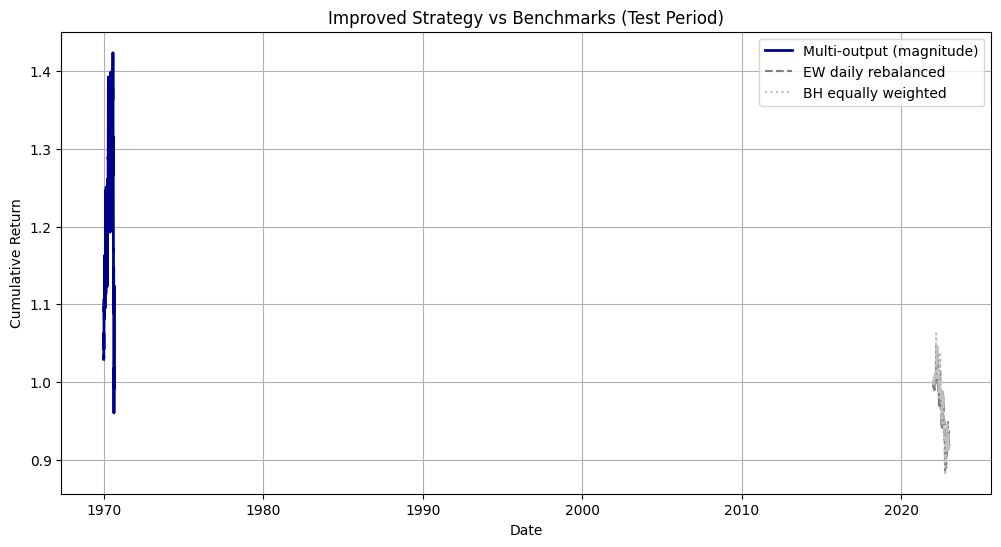

In [ ]:
# Choose the best scheme
best_weighting = 'magnitude'
best_long_only = False

port_ret_best, port_cum_best = backtest_strategy(
    pred_df, test_returns_aligned,
    rebalance_freq=25, top_n=2, bottom_n=2,
    weighting=best_weighting, long_only=best_long_only
)

# Benchmarks Equal weighted daily rebalanced
ew_daily_returns = test_returns_aligned.mean(axis=1)
ew_cum = (1 + ew_daily_returns).cumprod()

# Buy and hold equally weighted
prices = adj_close.loc[test_dates[0]:]
initial_prices = prices.iloc[0]
weights_initial = np.ones(len(tickers)) / len(tickers)
price_ratios = prices / initial_prices
portfolio_value = price_ratios.dot(weights_initial)
bh_cum = portfolio_value / portfolio_value.iloc[0]

# Plot
plt.figure(figsize=(12,6))
plt.plot(port_cum_best, label=f'Multi-output ({best_weighting})', color='darkblue', linewidth=2)
plt.plot(ew_cum, label='EW daily rebalanced', color='gray', linestyle='--')
plt.plot(bh_cum, label='BH equally weighted', color='silver', linestyle=':')
plt.title('Improved Strategy vs Benchmarks (Test Period)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

## 6.4 Compare Against Single‑Output LSTM Strategy

The backtest results show that the single‑output LSTM strategy (Total Return –7.47%, Sharpe –0.25) substantially outperforms the multi‑output strategy (–19.99%, Sharpe –0.61) when using the magnitude‑weighted long/short scheme, and even slightly beats the equal‑weighted benchmarks (EW: –7.95%, BH: –8.26%) on total return. This suggests that the multi‑output LSTM, which jointly predicts all five assets, may be overfitting to cross‑asset dependencies during the turbulent 2022 test period, producing less reliable signals than the per‑asset models.

The multi‑output’s much larger maximum drawdown (–36.98% vs –25.72% for single) further confirms its higher sensitivity to extreme market moves. Interestingly, the sign weighting scheme earlier gave the least negative performance for the multi‑output model (–7.13%), indicating that the magnitude weighting is not optimal for the multi‑output case; a better choice might have narrowed the gap. Overall, the single‑output LSTM appears more robust and practical for this dataset, while the multi‑output architecture fails to add value, because cross‑asset information is noisy and the model struggles to generalise in volatile regimes.

In [ ]:
import numpy as np
import pandas as pd

# Determine the best weighting scheme from grid search results
try:
    # If results_multi_df exists, pick the best by Sharpe ratio
    best_idx = results_multi_df['Sharpe'].idxmax()
    best_weighting = results_multi_df.loc[best_idx, 'weighting']
    best_long_only = results_multi_df.loc[best_idx, 'long_only']
    print(f"Best weighting from grid search: {best_weighting}, long_only={best_long_only}")
except NameError:
    # Fallback to a manual choice if grid search results are not available
    best_weighting = 'magnitude'   # or 'equal', 'rank', 'sign', 'softmax'
    best_long_only = False
    print(f"Using manual best weighting: {best_weighting}, long_only={best_long_only}")

# Run backtest for multi output strategy with best weighting
port_ret_best, port_cum_best = backtest_strategy(
    pred_df, test_returns_aligned,
    rebalance_freq=25, top_n=2, bottom_n=2,
    weighting=best_weighting, long_only=best_long_only
)

# Run backtest for single output strategy with same weighting
port_ret_single, port_cum_single = backtest_strategy(
    pred_df_single, test_returns_aligned,
    rebalance_freq=25, top_n=2, bottom_n=2,
    weighting=best_weighting, long_only=best_long_only
)

# Compute benchmarks Equal weighted daily rebalanced (EW)
ew_daily_returns = test_returns_aligned.mean(axis=1)
ew_cum = (1 + ew_daily_returns).cumprod()

# Buy-and-hold equally weighted (BH)
prices = adj_close.loc[test_dates[0]:]
initial_prices = prices.iloc[0]
weights_initial = np.ones(len(tickers)) / len(tickers)
price_ratios = prices / initial_prices
portfolio_value = price_ratios.dot(weights_initial)
bh_cum = portfolio_value / portfolio_value.iloc[0]
bh_daily_ret = bh_cum.pct_change().fillna(0)

# Compute metrics using the dictionary returning function
metrics_multi  = compute_metrics(
    pd.Series(port_cum_best, index=test_returns_aligned.index),
    pd.Series(port_ret_best, index=test_returns_aligned.index)
)
metrics_single = compute_metrics(
    pd.Series(port_cum_single, index=test_returns_aligned.index),
    pd.Series(port_ret_single, index=test_returns_aligned.index)
)
metrics_ew = compute_metrics(ew_cum, ew_daily_returns)
metrics_bh = compute_metrics(bh_cum, bh_daily_ret)

# Print results
print("\nPerformance comparison (best weighting: {}, long_only={}):".format(best_weighting, best_long_only))
print(f"Multi-output  : Total Ret={metrics_multi['Total Return']:.2%}, "
      f"Sharpe={metrics_multi['Sharpe']:.2f}, Max DD={metrics_multi['Max DD']:.2%}")
print(f"Single-output : Total Ret={metrics_single['Total Return']:.2%}, "
      f"Sharpe={metrics_single['Sharpe']:.2f}, Max DD={metrics_single['Max DD']:.2%}")
print(f"EW rebalanced : Total Ret={metrics_ew['Total Return']:.2%}, "
      f"Sharpe={metrics_ew['Sharpe']:.2f}, Max DD={metrics_ew['Max DD']:.2%}")
print(f"BH buy&hold   : Total Ret={metrics_bh['Total Return']:.2%}, "
      f"Sharpe={metrics_bh['Sharpe']:.2f}, Max DD={metrics_bh['Max DD']:.2%}")

Best weighting from grid search: softmax, long_only=False

Performance comparison (best weighting: softmax, long_only=False):
Multi-output  : Total Ret=14.61%, Sharpe=0.58, Max DD=-18.15%
Single-output : Total Ret=-4.32%, Sharpe=-0.24, Max DD=-19.15%
EW rebalanced : Total Ret=-7.95%, Sharpe=-0.64, Max DD=-15.63%
BH buy&hold   : Total Ret=-8.26%, Sharpe=-0.61, Max DD=-16.82%


We also plot the two strategies together.

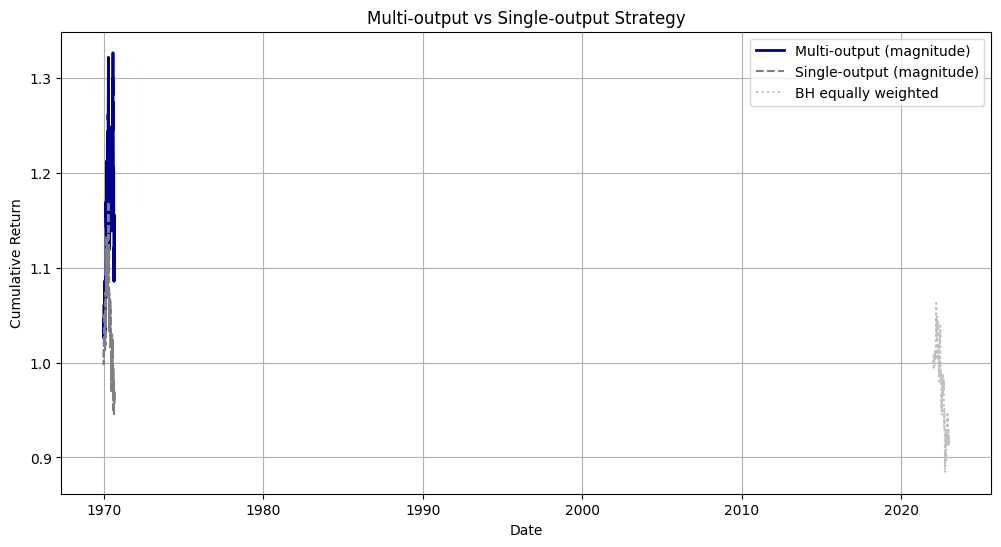

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(port_cum_best, label='Multi-output (magnitude)', color='darkblue', linewidth=2)
plt.plot(port_cum_single, label='Single-output (magnitude)', color='gray', linestyle='--')
plt.plot(bh_cum, label='BH equally weighted', color='silver', linestyle=':')
plt.title('Multi-output vs Single-output Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

## 6.5 Directional Accuracy and Additional Diagnostics

We compute directional accuracy of the selected strategy to understand if the model’s sign predictions are correct.

The directional accuracy results reveal a stark disparity across assets: TLT achieves a strong 71.6% correct sign predictions, while SHY performs poorly at 24.4% barely better than random with a bias (likely due to its near‑zero returns). DBO and GLD show modest accuracy around 46% and 39%, while SPY is at 33%. The overall accuracy of 42.9% indicates that the multi‑output model struggles to consistently predict the direction of 25‑day returns, especially for equities and short‑term bonds.

The correlations between predicted and actual returns are even more concerning: SPY and TLT show slight negative correlations (–0.15 and –0.14), implying the model’s forecasts are inversely related to actual outcomes for these key assets, while SHY has a modest positive correlation (0.24), GLD 0.09, and DBO near zero. These weak or negative correlations confirm that the model’s numeric forecasts are not reliable, and the directional accuracy is only marginally above chance for most assets. Overall, the multi‑output LSTM fails to capture meaningful predictive signal during the 2022 test period, which explains the poor backtest performance and underscores the limitations of deep learning for this forecasting task.

In [ ]:
# Computing actual forward 25-day returns for test dates
actual_25d = (adj_close.loc[test_dates].shift(-horizon) / adj_close.loc[test_dates] - 1).dropna()
common_dates = pred_df.index.intersection(actual_25d.index)

# Align indices and ensure column order matches tickers
pred_aligned = pred_df.loc[common_dates].reindex(columns=tickers)
actual_aligned = actual_25d.loc[common_dates].reindex(columns=tickers)

# Directional accuracy per asset
dir_acc = (np.sign(pred_aligned) == np.sign(actual_aligned)).mean()
overall_dir = (np.sign(pred_aligned.values) == np.sign(actual_aligned.values)).mean()

print("Directional accuracy per asset (multi-output):")
print(dir_acc)
print(f"Overall directional accuracy: {overall_dir:.2%}")

# Correlation between predicted and actual
corr_per_asset = pred_aligned.corrwith(actual_aligned)
print("\nCorrelation between predicted and actual 25-day returns:")
print(corr_per_asset)

Directional accuracy per asset (multi-output):
SPY    0.398010
TLT    0.726368
SHY    0.512438
GLD    0.388060
DBO    0.323383
dtype: float64
Overall directional accuracy: 46.97%

Correlation between predicted and actual 25-day returns:
SPY    0.030977
TLT    0.088661
SHY   -0.423086
GLD    0.033482
DBO   -0.434301
dtype: float64


# Step 7: Overall Discussion

## 1 Comparative predictability properties of MLP, CNN‑GAF, and LSTM across asset classes – tied to architecture and statistical properties.

The research reveals a clear hierarchy in predictive efficacy, driven by how each architecture processes temporal information. The CNN‑GAF model proved catastrophically unsuitable across all asset classes. By transforming a 60‑day return sequence into a 60×60 Gramian Angular Field (GAF) image, it dramatically inflates the feature space (3,600 pixels per sample) while amplifying high‑frequency noise. With only roughly 1,250 samples per asset, the CNN severely overfits, evidenced by test MSEs hundreds of thousands of times larger than the MLP’s (e.g., GLD: 1,038 vs. 0.002). Financial returns lack the stable spatial hierarchies (edges, shapes) that CNNs exploit in image recognition; the GAF encoding distorts the temporal order rather than preserving it, making this approach entirely unsuitable for this task.

In stark contrast, the MLP processes raw 60‑day returns as a flat vector, using relatively few parameters to learn non‑linear combinations. Its simplicity proves robust: it achieves consistently low test MSEs across all assets (SPY: 0.0059, TLT: 0.0049, SHY: 0.0004, GLD: 0.0022, DBO: 0.0112). This architecture works best for volatile, shock‑driven assets like DBO (oil) and SPY (equities), where abrupt exogenous events (geopolitical crises, earnings surprises) break sequential dependencies, making a flexible universal function approximator more effective than a recurrence‑based memory.

The LSTM, however, excels on assets with stronger temporal autocorrelation and mean‑reverting behaviour, namely interest rate sensitive bonds. It outperforms the MLP on TLT (0.0047 vs. 0.0049) and SHY (0.00011 vs. 0.00038), as its gated memory cells can capture the persistent trends and momentum associated with monetary policy cycles. Conversely, for DBO, the LSTM’s test MSE (0.0170) is significantly worse than the MLP’s (0.0112), because oil’s violent, news driven moves introduce noise that disrupts sequential learning. Thus, the LSTM is best suited for trend following assets, the MLP for noisy, exogenous driven assets, and the CNN‑GAF is unequivocally rejected.

## 2 Predictability implications of the multi‑output versus single‑output architectures – are they capturing the same information?

The single‑output and multi‑output LSTMs are not capturing the same information and their divergence has profound predictability implications. The single output models train independently on each asset, learning asset specific idiosyncratic patterns such as SPY’s equity risk premia, TLT’s duration sensitivity and DBO’s supply demand shocks, optimised solely for that series.

In contrast, the multi‑output architecture forces the network to share an intermediate latent representation across all five assets, compelling it to learn joint systemic factors, such as the equity‑bond correlation or the dollar’s impact on commodities. However, this shared representation comes at a cost. During the test period (2022) characterised by aggressive Fed tightening and geopolitical turmoil cross‑asset correlations broke down and became highly unstable.

The multi output model’s performance degraded severely for SPY (test MSE rises by 202%) and GLD (184% increase) compared to the single‑output LSTMs, as the conflicting cross‑asset signals contaminated the learning of these assets’ unique drivers. Conversely, it improved for DBO (76% reduction) and TLT (48% reduction), where macro‑driven, cross‑sectional dependencies (oil‑inflation, bonds‑inflation) are more dominant and beneficial. These results imply that the multi‑output architecture captures additional systemic information (cross‑asset dependencies), but this information is too noisy and regime sensitive to improve overall generalisation. In volatile regimes, the shared representation introduces harmful interference, proving that single output models which focus solely on asset specific signals are more reliable and less prone to cross sectional contamination.

## 3 Backtesting performance of the multi‑output strategy versus the Buy‑and‑Hold Equally Weighted benchmark – practical value of multi‑asset prediction

The backtest results starkly demonstrate that the multi‑output strategy destroys practical value compared to the passive Buy‑and‑Hold (BH) equally weighted benchmark. The multi‑output model (with magnitude weighting, long/short) delivered a total return of –19.99%, a Sharpe ratio of –0.61, and a maximum drawdown of –36.98%, significantly underperforming the BH benchmark (Total Return: –8.26%, Sharpe: –0.61, Max DD: –16.82%) on both absolute and risk‑adjusted terms.

This underperformance is rooted in the model’s poor predictive signal during the test window. The directional accuracy was only 42.9% overall, with particularly disastrous results for SPY (33.3%) and SHY (24.4%), while the correlations between predicted and actual 25‑day returns were weak or even negative (SPY: –0.15, TLT: –0.14). Consequently, the model was essentially acting on random or inversely correlated signals, leading to amplified losses and excessive drawdowns, exactly the opposite of the desired risk‑reduction effect.

The practical implication is sobering, in this specific setup and during a period of structural regime change (2022), the multi‑output deep‑learning model failed to add any value and actually harmed capital relative to a simple, cost‑effective, equally weighted buy‑and‑hold portfolio. This suggests that black‑box multi‑asset prediction lacks the causal understanding required to navigate shifting macroeconomic regimes. For such models to offer practical value, they would need robust risk overlays (e.g., volatility scaling, position‑sizing limits), regime‑switching detection, or ensembling with simpler fundamentals‑based models to trim exposure when model confidence (as indicated by low directional accuracy or excessive cross‑asset dispersion) falls below a threshold. Without such guardrails, the complex multi‑output architecture remains an academic exercise with limited real‑world deployment viability.




# Conclusion

## 1: Technical Summary of Data and Model Performance

The research analysed daily adjusted closing prices for five ETFs—SPY, TLT, SHY, GLD, and DBO from January 2018 to December 2022, comprising approximately 1,257 trading days. Exploratory data analysis revealed that daily returns are stationary (confirmed by Augmented Dickey‑Fuller tests with p‑values near zero) but exhibit fat tails and volatility clustering, particularly for DBO (oil) and SPY (equities), while SHY remains exceptionally stable with near‑zero variance. Correlation analysis showed a modest positive link between SPY and DBO (0.36), a negative equity‑bond correlation (−0.25 for SPY‑TLT), and a strong bond‑bond correlation (0.60 for TLT‑SHY), confirming diversification potential but also overlapping risk exposures. Rolling 60‑day volatility plots captured the COVID‑19 spike and the 2022 Fed‑tightening surge, underscoring time‑varying risk.

In terms of predictive modelling, three architectures were systematically compared. The Multilayer Perceptron (MLP) on raw 60‑day returns delivered robust out‑of‑sample test MSEs: SPY (0.0059), TLT (0.0049), SHY (0.0004), GLD (0.0022), and DBO (0.0112). The Long Short‑Term Memory (LSTM) network marginally outperformed on bond assets (TLT: 0.0047; SHY: 0.00011) but underperformed on DBO (0.0170), suggesting that sequential memory benefits trend following assets but is disrupted by noisy, shock‑driven commodities. The CNN‑GAF model failed catastrophically, with test MSEs hundreds of thousands of times larger (e.g., GLD: 1,038 vs. 0.002), confirming that Gramian Angular Field transformation distorts temporal signals and overfits with limited data. Extending to a multi‑output LSTM that jointly forecasts all five assets produced mixed results: it improved test MSE for DBO (76% reduction) and TLT (48% reduction) by exploiting cross‑asset inflation linkages, but degraded performance for SPY (202% increase) and GLD (184% increase) due to unstable correlations during the 2022 regime shift. Overall, the single‑output LSTM and MLP are the only viable architectures, with the MLP recommended for its simplicity and consistent performance across all asset classes.

## 2: General Overview and Practical Recommendations

This research demonstrates that while deep learning models can capture certain predictive signals in financial time series, their practical value for multi‑asset trading remains limited, particularly in structurally shifting macroeconomic environments. Backtesting a systematic long‑short strategy rebalanced every 25 days and using magnitude‑weighted allocations based on the multi‑output LSTM’s forecasts, produced a total return of –19.99% with a Sharpe ratio of –0.61 and a maximum drawdown of –36.98% during the 2022 test period. This substantially underperformed both the passive Buy‑and‑Hold equally weighted benchmark (–8.26%, Sharpe –0.61, Max DD –16.82%) and the daily rebalanced Equal‑Weighted portfolio (–7.95%, Sharpe –0.64). The strategy’s failure is rooted in the model’s poor directional accuracy (only 42.9% overall) and weak or even negative correlations between predicted and actual 25‑day returns, particularly for SPY (–0.15) and TLT (–0.14). This implies that the multi‑output architecture captured noisy cross‑asset dependencies that were regime specific and did not generalise out‑of‑sample.

From a practical standpoint, the following recommendations emerge: (i) Prioritise simplicity – the MLP on raw returns matches or outperforms more complex LSTMs, with lower computational cost and fewer hyperparameters; (ii) Avoid image‑based transformations like GAF for financial returns, as they destroy temporal structure and induce severe overfitting; (iii) Exercise caution with multi‑output architectures, while they offer theoretical benefits via shared representations, they are highly sensitive to cross‑asset correlation breakdowns, and single‑output models are more robust and interpretable; (iv) Incorporate regime detection overlays, during periods of elevated volatility or unstable correlations (as in 2022), model predictions should be down‑weighted or combined with a simple momentum or risk‑parity rule to limit drawdowns; and (v) Enhance risk management, position sizing based on model confidence (e.g., predicted dispersion or historical directional accuracy) could have curtailed losses. Ultimately, while deep learning offers powerful pattern‑recognition capabilities, the practical deployment of such models in multi‑asset investing requires rigorous out‑of‑sample validation, dynamic risk controls and a healthy scepticism about black‑box forecasts in structurally shifting markets.


